# PREDICCIÓN DE LA CALIDAD DEL SUEÑO

El objetivo al que tratamos de llegar se basa en lograr predecir la calidad 
del sueño mediante los datos fisiológicos extraídos de las mediciones con el O2Ring y el test de Pittsburgh  

El problema es de tipo clasificación ya que la variable a predecir es de tipo discreta (calidad del sueño en categorías: "buena", "regular", "mala")

In [105]:
# Importar librerías necesarias
import numpy as np
import time
import warnings

import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.font_manager as font_manager
import matplotlib.cbook

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.neighbors import KNeighborsClassifier

from sklearn.utils import class_weight

from sklearn.metrics import accuracy_score
from sklearn.metrics import cohen_kappa_score
from sklearn.metrics import roc_curve, auc, confusion_matrix

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score

#import utilities
import multiprocessing
#import get_parameters

import pandas as pd
import glob

## 1. CARGAR DATOS

### O2RING

IMPORTAMOS LOS DATOS DEL O2Ring  

Cada paciente está en un csv diferente dentro de la carpeta de O2Ring, por lo que usamos la función glob para encontrar todos los csv (ya que busca archivos que coinciden con un patrón --> /*.csv)

In [106]:
# glob encuentra nombres de archivos que coinciden con un patrón
medic_csv = glob.glob("C:/Users/Marina/OneDrive - Universidad de Burgos/Escritorio/OneDrive - Universidad de Burgos/Escritorio/TFG/O2Ring/*.csv")

In [107]:
# almacenar los datos de cada pacienete
lista_o2ring = []

for archivo in medic_csv:
    pac_data = pd.read_csv(archivo)
    pac_data['Paciente_ID'] = archivo.split('-')[-1].split('.')[0] 
    lista_o2ring.append(pac_data)

# concatenar datos
o2ring = pd.concat(lista_o2ring, ignore_index=True)

#print(data)
o2ring.head()

,Time,SpO2(%),Pulse Rate(bpm),Motion,SpO2 Reminder,PR Reminder,Unnamed: 6,Paciente_ID
0,"12:26:18AM Nov 13, 2024",96,73,0,0,0,NaN,Alvaro
1,"12:26:22AM Nov 13, 2024",96,73,1,0,0,NaN,Alvaro
2,"12:26:26AM Nov 13, 2024",96,74,0,0,0,NaN,Alvaro
3,"12:26:30AM Nov 13, 2024",96,73,1,0,0,NaN,Alvaro
4,"12:26:34AM Nov 13, 2024",96,72,9,0,0,NaN,Alvaro


### TEST DE PITTSBURGH

El test de Pittsburgh ha sido realizado en Google Forms, cada participante lo ha completado de forma individual y con información a cerca de su calidad del sueño durante el último mes


In [108]:
ruta_test = "C:/Users/Marina/OneDrive - Universidad de Burgos/Escritorio/OneDrive - Universidad de Burgos/Escritorio/TFG/TestPittsburgh/Test_Pittsburgh(respuestas)4.csv"
# Leer los datos del Test de Pittsburgh
test_pittsburgh = pd.read_csv(ruta_test)
test_pittsburgh.head(30)

,Marca temporal,Escriba su nombre:,¿Cuál es su edad?,¿Cuánto pesa y cuál es su altura? (kg y cm si es posible),1. ¿Con qué frecuencia ha tenido problemas para quedarse dormido durante el último mes?,2. ¿Con qué frecuencia ha despertado durante la noche y no ha podido volver a dormir?,3. ¿Con qué frecuencia ha tenido dificultad para despertarse por la mañana?,4. ¿Con qué frecuencia se ha sentido cansado o somnoliento durante el día?,5. ¿Con qué frecuencia ha tenido sueños agitados o pesadillas?,6. ¿Con qué frecuencia ha tenido problemas para mantenerse despierto mientras realiza actividades durante el día?,...,"11. ¿Con qué frecuencia ha tenido problemas con el sueño debido a su estado emocional (depresión, estrés, etc.)?",12. ¿Cuánto tiempo tarda habitualmente en quedarse dormido después de acostarse?,13. ¿Cuántas horas de sueño promedio tiene cada noche?,14. ¿Con qué frecuencia ha tenido interrupciones en el sueño debido a ir al baño?,15. ¿Con qué frecuencia ha tenido problemas para dormir debido a preocupaciones o pensamientos?,16. ¿Con qué frecuencia ha tenido dificultades para mantener una rutina regular de sueño (ir a la cama y despertarse a la misma hora cada día)?,17. ¿Con qué frecuencia se siente descansado después de dormir toda la noche?,"18. ¿Con qué frecuencia ha tenido problemas de sueño que han afectado su capacidad para trabajar, estudiar o realizar otras actividades diarias?",19. ¿Con qué frecuencia ha tenido síntomas físicos como dolor o malestar que han afectado a su sueño?,"20. Durante el último mes, ¿cómo valoraría, en conjunto, la calidad de su sueño?"
0,20/11/2024 10:04:39,Marina,22,63 y 170,A veces,Nunca,Nunca,A veces,Nunca,Nunca,...,Nunca,entre 16 y 30 minutos,más de 7 horas,Menos de una vez a la semana,Nunca,A veces,Frecuentemente,Nunca,Nunca,Bastante buena
1,20/11/2024 10:10:59,Paula,21,56 y 174,A veces,Nunca,A veces,Frecuentemente,Frecuentemente,Nunca,...,A veces,entre 16 y 30 minutos,entre 6 - 7 horas,Ninguna vez en el último mes,A veces,A veces,A veces,A veces,Frecuentemente,Bastante buena
2,20/11/2024 10:14:08,Elena,22,53 y 160,A veces,Nunca,Nunca,Nunca,A veces,A veces,...,A veces,entre 31 minutos y 1 hora,entre 5 -6 horas,Menos de una vez a la semana,A veces,A veces,A veces,Frecuentemente,A veces,Bastante buena
3,20/11/2024 10:17:48,Carmen,21,66 y 163,A veces,Nunca,Siempre,Frecuentemente,A veces,A veces,...,A veces,menos de 15 minutos,entre 6 - 7 horas,Ninguna vez en el último mes,A veces,A veces,Frecuentemente,A veces,Nunca,Bastante buena
4,20/11/2024 10:21:23,PaulaMunoa,20,52 y 163,Frecuentemente,A veces,Nunca,A veces,A veces,Nunca,...,Frecuentemente,entre 16 y 30 minutos,entre 6 - 7 horas,Menos de una vez a la semana,Frecuentemente,A veces,A veces,A veces,A veces,Bastante buena
5,20/11/2024 11:41:55,Santiago,26,80 y 175,A veces,Nunca,A veces,A veces,Frecuentemente,A veces,...,A veces,entre 16 y 30 minutos,entre 5 -6 horas,Menos de una vez a la semana,A veces,A veces,Frecuentemente,A veces,Nunca,Bastante buena
6,20/11/2024 11:47:42,Alvaro,20,78 y 175,Nunca,Nunca,A veces,A veces,A veces,A veces,...,Nunca,menos de 15 minutos,entre 6 - 7 horas,Ninguna vez en el último mes,Nunca,Frecuentemente,A veces,A veces,A veces,Bastante buena
7,22/11/2024 10:53:51,Jaime,20,115 y 178,Nunca,Nunca,Frecuentemente,Frecuentemente,A veces,A veces,...,Nunca,menos de 15 minutos,entre 6 - 7 horas,1 o 2 veces a la semana,Nunca,A veces,A veces,A veces,Nunca,Bastante mala
8,24/11/2024 23:22:49,Javier,51,73 kg 174 cm,A veces,Nunca,Nunca,A veces,A veces,A veces,...,A veces,entre 16 y 30 minutos,entre 5 -6 horas,Ninguna vez en el último mes,A veces,A veces,Frecuentemente,A veces,A veces,Bastante buena
9,25/11/2024 8:35:13,Ana,46,57 y 173,Nunca,Nunca,Siempre,A veces,A veces,A veces,...,Nunca,menos de 15 minutos,entre 6 - 7 horas,Ninguna vez en el último mes,Nunca,A veces,A veces,A veces,A veces,Muy buena


### LISTA DE PERSONAS (excel)

In [109]:
# Importar los datos de la lista de personas (excel)
ruta_lista_personas ="C:/Users/Marina/OneDrive - Universidad de Burgos/Escritorio/TFG/ListaPersonas1.xlsx"


# Leer los datos demográficos de los pacientes
lista_personas = pd.read_excel(ruta_lista_personas)

# Mostrar las primeras filas 
lista_personas.head(30)

,Unnamed: 0,Sujeto,Edad (años),Peso (kg),Altura (m),IMC,Sexo,Fecha prueba 1,Qué tal ha dormido,Fecha prueba 2
0,1,Marina,22,63,1.70,21.799308,Femenino,2024-10-24,Mal,NaT
1,2,Alvaro,20,78,1.75,25.469388,Masculino,2024-11-12,Regular,NaT
2,3,PaulaMunoa,20,53,1.63,19.948060,Femenino,2024-11-13,Mal,NaT
3,4,Carmen,21,66,1.63,24.840980,Femenino,2024-11-14,Bien,NaT
4,5,Paula,21,56,1.74,18.496499,Femenino,2024-11-17,Bien pero poco,2024-11-20
5,6,Santiago,26,80,1.75,26.122449,Masculino,2024-11-18,Bien,NaT
6,7,Elena,22,53,1.60,20.703125,Femenino,2024-11-19,Muy bien,NaT
7,8,Jaime,20,115,1.78,36.295922,Masculino,2024-11-21,Bien,NaT
8,9,Javier,51,73,1.74,24.111507,Masculino,2024-12-03,Bien,NaT
9,10,Ana,46,57,1.73,19.045073,Femenino,2024-11-24,Bien,NaT


In [110]:
# Importar los datos de la lista de personas (excel)
ruta_lista_personas ="C:/Users/Marina/OneDrive - Universidad de Burgos/Escritorio/OneDrive - Universidad de Burgos/Escritorio/TFG/ListaPersonas1.xlsx"


# Leer los datos demográficos de los pacientes
lista_personas = pd.read_excel(ruta_lista_personas)

# Mostrar las primeras filas 
lista_personas.head(30)

,Unnamed: 0,Sujeto,Edad (años),Peso (kg),Altura (m),IMC,Sexo,Fecha prueba 1,Qué tal ha dormido,Fecha prueba 2
0,1,Marina,22,63,1.70,21.799308,Femenino,2024-10-24,Mal,NaT
1,2,Alvaro,20,78,1.75,25.469388,Masculino,2024-11-12,Regular,NaT
2,3,PaulaMunoa,20,53,1.63,19.948060,Femenino,2024-11-13,Mal,NaT
3,4,Carmen,21,66,1.63,24.840980,Femenino,2024-11-14,Bien,NaT
4,5,Paula,21,56,1.74,18.496499,Femenino,2024-11-17,Bien pero poco,2024-11-20
5,6,Santiago,26,80,1.75,26.122449,Masculino,2024-11-18,Bien,NaT
6,7,Elena,22,53,1.60,20.703125,Femenino,2024-11-19,Muy bien,NaT
7,8,Jaime,20,115,1.78,36.295922,Masculino,2024-11-21,Bien,NaT
8,9,Javier,51,73,1.74,24.111507,Masculino,2024-12-03,Bien,NaT
9,10,Ana,46,57,1.73,19.045073,Femenino,2024-11-24,Bien,NaT


Comprobamos todos las colecciones cargadas, asi como que podemos visualizarlas antes de continuar con el resto de pasos.

In [111]:
print("Tamaño del dataset O2Ring:", o2ring.shape)
print("Tamaño del test de Pittsburgh:", test_pittsburgh.shape)
print("Tamaño de la lista de personas:", lista_personas.shape)


Tamaño del dataset O2Ring: (178147, 8)
Tamaño del test de Pittsburgh: (25, 24)
Tamaño de la lista de personas: (25, 10)


In [112]:
print("Datos O2Ring: ")
display(o2ring.head())
print("Datos del Test de Pittsburgh: ")
display(test_pittsburgh.head())
print("Datos de la lista de personas: ")
display(lista_personas.head())


Datos O2Ring: 


,Time,SpO2(%),Pulse Rate(bpm),Motion,SpO2 Reminder,PR Reminder,Unnamed: 6,Paciente_ID
0,"12:26:18AM Nov 13, 2024",96,73,0,0,0,NaN,Alvaro
1,"12:26:22AM Nov 13, 2024",96,73,1,0,0,NaN,Alvaro
2,"12:26:26AM Nov 13, 2024",96,74,0,0,0,NaN,Alvaro
3,"12:26:30AM Nov 13, 2024",96,73,1,0,0,NaN,Alvaro
4,"12:26:34AM Nov 13, 2024",96,72,9,0,0,NaN,Alvaro


Datos del Test de Pittsburgh: 


,Marca temporal,Escriba su nombre:,¿Cuál es su edad?,¿Cuánto pesa y cuál es su altura? (kg y cm si es posible),1. ¿Con qué frecuencia ha tenido problemas para quedarse dormido durante el último mes?,2. ¿Con qué frecuencia ha despertado durante la noche y no ha podido volver a dormir?,3. ¿Con qué frecuencia ha tenido dificultad para despertarse por la mañana?,4. ¿Con qué frecuencia se ha sentido cansado o somnoliento durante el día?,5. ¿Con qué frecuencia ha tenido sueños agitados o pesadillas?,6. ¿Con qué frecuencia ha tenido problemas para mantenerse despierto mientras realiza actividades durante el día?,...,"11. ¿Con qué frecuencia ha tenido problemas con el sueño debido a su estado emocional (depresión, estrés, etc.)?",12. ¿Cuánto tiempo tarda habitualmente en quedarse dormido después de acostarse?,13. ¿Cuántas horas de sueño promedio tiene cada noche?,14. ¿Con qué frecuencia ha tenido interrupciones en el sueño debido a ir al baño?,15. ¿Con qué frecuencia ha tenido problemas para dormir debido a preocupaciones o pensamientos?,16. ¿Con qué frecuencia ha tenido dificultades para mantener una rutina regular de sueño (ir a la cama y despertarse a la misma hora cada día)?,17. ¿Con qué frecuencia se siente descansado después de dormir toda la noche?,"18. ¿Con qué frecuencia ha tenido problemas de sueño que han afectado su capacidad para trabajar, estudiar o realizar otras actividades diarias?",19. ¿Con qué frecuencia ha tenido síntomas físicos como dolor o malestar que han afectado a su sueño?,"20. Durante el último mes, ¿cómo valoraría, en conjunto, la calidad de su sueño?"
0,20/11/2024 10:04:39,Marina,22,63 y 170,A veces,Nunca,Nunca,A veces,Nunca,Nunca,...,Nunca,entre 16 y 30 minutos,más de 7 horas,Menos de una vez a la semana,Nunca,A veces,Frecuentemente,Nunca,Nunca,Bastante buena
1,20/11/2024 10:10:59,Paula,21,56 y 174,A veces,Nunca,A veces,Frecuentemente,Frecuentemente,Nunca,...,A veces,entre 16 y 30 minutos,entre 6 - 7 horas,Ninguna vez en el último mes,A veces,A veces,A veces,A veces,Frecuentemente,Bastante buena
2,20/11/2024 10:14:08,Elena,22,53 y 160,A veces,Nunca,Nunca,Nunca,A veces,A veces,...,A veces,entre 31 minutos y 1 hora,entre 5 -6 horas,Menos de una vez a la semana,A veces,A veces,A veces,Frecuentemente,A veces,Bastante buena
3,20/11/2024 10:17:48,Carmen,21,66 y 163,A veces,Nunca,Siempre,Frecuentemente,A veces,A veces,...,A veces,menos de 15 minutos,entre 6 - 7 horas,Ninguna vez en el último mes,A veces,A veces,Frecuentemente,A veces,Nunca,Bastante buena
4,20/11/2024 10:21:23,PaulaMunoa,20,52 y 163,Frecuentemente,A veces,Nunca,A veces,A veces,Nunca,...,Frecuentemente,entre 16 y 30 minutos,entre 6 - 7 horas,Menos de una vez a la semana,Frecuentemente,A veces,A veces,A veces,A veces,Bastante buena


Datos de la lista de personas: 


,Unnamed: 0,Sujeto,Edad (años),Peso (kg),Altura (m),IMC,Sexo,Fecha prueba 1,Qué tal ha dormido,Fecha prueba 2
0,1,Marina,22,63,1.70,21.799308,Femenino,2024-10-24,Mal,NaT
1,2,Alvaro,20,78,1.75,25.469388,Masculino,2024-11-12,Regular,NaT
2,3,PaulaMunoa,20,53,1.63,19.948060,Femenino,2024-11-13,Mal,NaT
3,4,Carmen,21,66,1.63,24.840980,Femenino,2024-11-14,Bien,NaT
4,5,Paula,21,56,1.74,18.496499,Femenino,2024-11-17,Bien pero poco,2024-11-20


In [113]:
display(lista_personas[['Sujeto', 'Peso (kg)', 'Altura (m)', 'IMC']].head(10))

,Sujeto,Peso (kg),Altura (m),IMC
0,Marina,63,1.70,21.799308
1,Alvaro,78,1.75,25.469388
2,PaulaMunoa,53,1.63,19.948060
3,Carmen,66,1.63,24.840980
4,Paula,56,1.74,18.496499
5,Santiago,80,1.75,26.122449
6,Elena,53,1.60,20.703125
7,Jaime,115,1.78,36.295922
8,Javier,73,1.74,24.111507
9,Ana,57,1.73,19.045073


## 2. PREPROCESAMIENTO Y LIMPIEZA DE DATOS

### O2Ring

Se eliminaron las columnas:
- Unnamed: 6, como su nombre indica no tiene ningun tipo de sentido en los distintos csv
- SpO2 Reminder y PR Reminder, yaque  hacen referencia a las alarmas vibratorias del dispositivo  para avisar a los pacientes que están por debajo o encima de algún límite que se ha determinado. En nuestro caso, fueron desactivadas, por lo que no cobran relevancia

In [114]:
# Renombrar columnas
df_o2ring = o2ring.rename(columns={
    "SpO2(%)": "SpO2",
    "Pulse Rate(bpm)": "Frec_Cardiaca",
    "Motion": "Movimiento"
})

# Convertir la columna de tiempo al tipo datetime
df_o2ring["Time"] = pd.to_datetime(df_o2ring["Time"])


# Eliminar columnas innecesarias y valores inválidos
df_o2ring = df_o2ring.drop(columns=["Unnamed: 6","SpO2 Reminder","PR Reminder"])

# La saturación nunca puede estar por encima de 100
df_o2ring = df_o2ring[df_o2ring["SpO2"] <= 100].dropna()


df_o2ring.head()


,Time,SpO2,Frec_Cardiaca,Movimiento,Paciente_ID
0,2024-11-13 00:26:18,96,73,0,Alvaro
1,2024-11-13 00:26:22,96,73,1,Alvaro
2,2024-11-13 00:26:26,96,74,0,Alvaro
3,2024-11-13 00:26:30,96,73,1,Alvaro
4,2024-11-13 00:26:34,96,72,9,Alvaro


### TEST DE PITTSBURGH

In [115]:
# renombrar las columnas
nombres_columnas = {
    "Marca temporal": "Fecha",
    "Escriba su nombre: " : "ID_Paciente",
    "¿Cuál es su edad?": "Edad",
    "¿Cuánto pesa y cuál es su altura? (kg y cm si es posible)": "Peso_Altura",
    "1. ¿Con qué frecuencia ha tenido problemas para quedarse dormido durante el último mes?": "Dormir_Problema",
    "2. ¿Con qué frecuencia ha despertado durante la noche y no ha podido volver a dormir?": "Despertar_Noche",
    "3. ¿Con qué frecuencia ha tenido dificultad para despertarse por la mañana?": "Despertar_Problema",
    "4. ¿Con qué frecuencia se ha sentido cansado o somnoliento durante el día?": "Somnolencia_Dia",
    "5. ¿Con qué frecuencia ha tenido sueños agitados o pesadillas?": "Pesadillas",
    "6. ¿Con qué frecuencia ha tenido problemas para mantenerse despierto mientras realiza actividades durante el día?": "Sueño_Tareas",
    "7. ¿Con qué frecuencia se ha despertado debido a problemas respiratorios (ronquidos, falta de aire, etc.)?": "Despertar_ProblemaRespirat",
    "8. ¿Con qué frecuencia se ha sentido nervioso o ansioso debido a sus problemas de sueño?": "Ansia_ProblSueño",
    "9. ¿Con qué frecuencia ha tenido dificultades para concentrarse durante el día debido a su falta de sueño?": "Concentr_Sueño",
    "10. ¿Con qué frecuencia ha tenido dolor de cabeza por la mañana?": "DolorCabeza_Mañana",
    "11. ¿Con qué frecuencia ha tenido problemas con el sueño debido a su estado emocional (depresión, estrés, etc.)?  ": "ProbSueño_EstadoEmoc",
    "12. ¿Cuánto tiempo tarda habitualmente en quedarse dormido después de acostarse?    ": "Tiempo_Dormir",
    "13. ¿Cuántas horas de sueño promedio tiene cada noche?": "Horas_Sueño",
    "14. ¿Con qué frecuencia ha tenido interrupciones en el sueño debido a ir al baño?": "InterrupSueño_Baño",
    "15. ¿Con qué frecuencia ha tenido problemas para dormir debido a preocupaciones o pensamientos?": "ProblDormir_Preocupac",
    "16. ¿Con qué frecuencia ha tenido dificultades para mantener una rutina regular de sueño (ir a la cama y despertarse a la misma hora cada día)?  ": "Dificultades_RutinaSueño",
    "17. ¿Con qué frecuencia se siente descansado después de dormir toda la noche?  ": "Descansado_Frecuencia",
    "18. ¿Con qué frecuencia  ha tenido problemas de sueño que han afectado su capacidad para trabajar, estudiar o realizar otras actividades diarias?  ": "ProblemasSueño_Trabajar",
    "19. ¿Con qué frecuencia ha tenido síntomas físicos como dolor o malestar que han afectado a su sueño?": "Dolor_AfectaSueño",
    "20. Durante el último mes, ¿cómo valoraría, en conjunto, la calidad de su sueño?": "Calidad_Sueño"
    
}

test_pittsburgh.rename(columns=nombres_columnas, inplace=True)

test_pittsburgh.head(26)


,Fecha,ID_Paciente,Edad,Peso_Altura,Dormir_Problema,Despertar_Noche,Despertar_Problema,Somnolencia_Dia,Pesadillas,Sueño_Tareas,...,ProbSueño_EstadoEmoc,Tiempo_Dormir,Horas_Sueño,InterrupSueño_Baño,ProblDormir_Preocupac,Dificultades_RutinaSueño,Descansado_Frecuencia,ProblemasSueño_Trabajar,Dolor_AfectaSueño,Calidad_Sueño
0,20/11/2024 10:04:39,Marina,22,63 y 170,A veces,Nunca,Nunca,A veces,Nunca,Nunca,...,Nunca,entre 16 y 30 minutos,más de 7 horas,Menos de una vez a la semana,Nunca,A veces,Frecuentemente,Nunca,Nunca,Bastante buena
1,20/11/2024 10:10:59,Paula,21,56 y 174,A veces,Nunca,A veces,Frecuentemente,Frecuentemente,Nunca,...,A veces,entre 16 y 30 minutos,entre 6 - 7 horas,Ninguna vez en el último mes,A veces,A veces,A veces,A veces,Frecuentemente,Bastante buena
2,20/11/2024 10:14:08,Elena,22,53 y 160,A veces,Nunca,Nunca,Nunca,A veces,A veces,...,A veces,entre 31 minutos y 1 hora,entre 5 -6 horas,Menos de una vez a la semana,A veces,A veces,A veces,Frecuentemente,A veces,Bastante buena
3,20/11/2024 10:17:48,Carmen,21,66 y 163,A veces,Nunca,Siempre,Frecuentemente,A veces,A veces,...,A veces,menos de 15 minutos,entre 6 - 7 horas,Ninguna vez en el último mes,A veces,A veces,Frecuentemente,A veces,Nunca,Bastante buena
4,20/11/2024 10:21:23,PaulaMunoa,20,52 y 163,Frecuentemente,A veces,Nunca,A veces,A veces,Nunca,...,Frecuentemente,entre 16 y 30 minutos,entre 6 - 7 horas,Menos de una vez a la semana,Frecuentemente,A veces,A veces,A veces,A veces,Bastante buena
5,20/11/2024 11:41:55,Santiago,26,80 y 175,A veces,Nunca,A veces,A veces,Frecuentemente,A veces,...,A veces,entre 16 y 30 minutos,entre 5 -6 horas,Menos de una vez a la semana,A veces,A veces,Frecuentemente,A veces,Nunca,Bastante buena
6,20/11/2024 11:47:42,Alvaro,20,78 y 175,Nunca,Nunca,A veces,A veces,A veces,A veces,...,Nunca,menos de 15 minutos,entre 6 - 7 horas,Ninguna vez en el último mes,Nunca,Frecuentemente,A veces,A veces,A veces,Bastante buena
7,22/11/2024 10:53:51,Jaime,20,115 y 178,Nunca,Nunca,Frecuentemente,Frecuentemente,A veces,A veces,...,Nunca,menos de 15 minutos,entre 6 - 7 horas,1 o 2 veces a la semana,Nunca,A veces,A veces,A veces,Nunca,Bastante mala
8,24/11/2024 23:22:49,Javier,51,73 kg 174 cm,A veces,Nunca,Nunca,A veces,A veces,A veces,...,A veces,entre 16 y 30 minutos,entre 5 -6 horas,Ninguna vez en el último mes,A veces,A veces,Frecuentemente,A veces,A veces,Bastante buena
9,25/11/2024 8:35:13,Ana,46,57 y 173,Nunca,Nunca,Siempre,A veces,A veces,A veces,...,Nunca,menos de 15 minutos,entre 6 - 7 horas,Ninguna vez en el último mes,Nunca,A veces,A veces,A veces,A veces,Muy buena


In [116]:
# MAPEO DE RESPUESTAS DEL TEST DE PITTSBURGH

mapeo_frecuencia = {
    "Nunca": 0, 
    "A veces": 1, 
    "Frecuentemente": 2, 
    "Siempre": 3
}

mapeo_calidad_sueño = {
    "Muy buena": 0,
    "Bastante buena": 1,
    "Bastante mala": 2,
    "Mala": 3
}

mapeo_tiempo_dormir = {
    "menos de 15 minutos": 0,
    "entre 16 y 30 minutos": 1,
    "entre 31 minutos y 1 hora": 2,
    "más de 1 hora": 3
}

mapeo_horas_sueño = {
    "más de 7 horas": 0,
    "entre 6 - 7 horas": 1,
    "entre 5 -6 horas": 2,
    "menos de 5 horas": 3
}

mapeo_interrupcion_sueño = {
    "Ninguna vez en el último mes": 0,
    "Menos de una vez a la semana": 1,
    "1 o 2 veces a la semana": 2,
    "3 o más veces a la semana": 3
}

# APLICAR MAPEO A LAS COLUMNAS CORRESPONDIENTES
columnas_frecuencia = [
    "Dormir_Problema", "Despertar_Noche", "Despertar_Problema", "Somnolencia_Dia",
    "Pesadillas", "Sueño_Tareas", "Despertar_ProblemaRespirat", "Ansia_ProblSueño",
    "Concentr_Sueño", "DolorCabeza_Mañana", "ProbSueño_EstadoEmoc",
    "ProblDormir_Preocupac", "Dificultades_RutinaSueño", "Descansado_Frecuencia",
    "ProblemasSueño_Trabajar", "Dolor_AfectaSueño"
]

for col in columnas_frecuencia:
    test_pittsburgh[col] = test_pittsburgh[col].map(mapeo_frecuencia)

test_pittsburgh["Tiempo_Dormir"] = test_pittsburgh["Tiempo_Dormir"].map(mapeo_tiempo_dormir)
test_pittsburgh["Horas_Sueño"] = test_pittsburgh["Horas_Sueño"].map(mapeo_horas_sueño)
test_pittsburgh["InterrupSueño_Baño"] = test_pittsburgh["InterrupSueño_Baño"].map(mapeo_interrupcion_sueño)
test_pittsburgh["Calidad_Sueño"] = test_pittsburgh["Calidad_Sueño"].map(mapeo_calidad_sueño)

# IMPRIMIR RESULTADOS PARA VERIFICAR LIMPIEZA
test_pittsburgh.head()


,Fecha,ID_Paciente,Edad,Peso_Altura,Dormir_Problema,Despertar_Noche,Despertar_Problema,Somnolencia_Dia,Pesadillas,Sueño_Tareas,...,ProbSueño_EstadoEmoc,Tiempo_Dormir,Horas_Sueño,InterrupSueño_Baño,ProblDormir_Preocupac,Dificultades_RutinaSueño,Descansado_Frecuencia,ProblemasSueño_Trabajar,Dolor_AfectaSueño,Calidad_Sueño
0,20/11/2024 10:04:39,Marina,22,63 y 170,1,0,0,1,0,0,...,0,1,0,1,0,1,2,0,0,1
1,20/11/2024 10:10:59,Paula,21,56 y 174,1,0,1,2,2,0,...,1,1,1,0,1,1,1,1,2,1
2,20/11/2024 10:14:08,Elena,22,53 y 160,1,0,0,0,1,1,...,1,2,2,1,1,1,1,2,1,1
3,20/11/2024 10:17:48,Carmen,21,66 y 163,1,0,3,2,1,1,...,1,0,1,0,1,1,2,1,0,1
4,20/11/2024 10:21:23,PaulaMunoa,20,52 y 163,2,1,0,1,1,0,...,2,1,1,1,2,1,1,1,1,1


### LISTA PERSONAS (excel)

In [117]:
# Renombrar la columna "Sujeto" a "Paciente_ID" en lista_personas
lista_personas.rename(columns={"Sujeto": "Paciente_ID"}, inplace=True)
lista_personas = lista_personas.drop(columns=["Unnamed: 0", "Fecha prueba 2"], errors="ignore")

lista_personas.head(25)

,Paciente_ID,Edad (años),Peso (kg),Altura (m),IMC,Sexo,Fecha prueba 1,Qué tal ha dormido
0,Marina,22,63,1.70,21.799308,Femenino,2024-10-24,Mal
1,Alvaro,20,78,1.75,25.469388,Masculino,2024-11-12,Regular
2,PaulaMunoa,20,53,1.63,19.948060,Femenino,2024-11-13,Mal
3,Carmen,21,66,1.63,24.840980,Femenino,2024-11-14,Bien
4,Paula,21,56,1.74,18.496499,Femenino,2024-11-17,Bien pero poco
5,Santiago,26,80,1.75,26.122449,Masculino,2024-11-18,Bien
6,Elena,22,53,1.60,20.703125,Femenino,2024-11-19,Muy bien
7,Jaime,20,115,1.78,36.295922,Masculino,2024-11-21,Bien
8,Javier,51,73,1.74,24.111507,Masculino,2024-12-03,Bien
9,Ana,46,57,1.73,19.045073,Femenino,2024-11-24,Bien


In [118]:
# 1. Convertir 'Sexo' a valores numéricos
mapa_sexo = {"Femenino": 0, "Masculino": 1}
lista_personas["Sexo_Codificado"] = lista_personas["Sexo"].map(mapa_sexo)

# 2. Normalizar 'Qué tal ha dormido'
mapa_sueño = {
    "Muy bien": 5,
    "Bien": 4,
    "Bien pero poco": 3,
    "Regular": 2,
    "Mal": 1
}
lista_personas["Calidad_Sueño_Subjet"] = lista_personas[" Qué tal ha dormido"].map(mapa_sueño)

# 3. Convertir 'Fecha prueba 1' a formato datetime
lista_personas["Fecha prueba 1"] = pd.to_datetime(lista_personas["Fecha prueba 1"], errors="coerce")

# 4. Verificar y manejar valores nulos
print("Valores nulos antes de limpieza:")
print(lista_personas.isnull().sum())

# Si hay valores nulos en 'Calidad_Sueño_Label' o 'Sexo_Codificado', eliminarlos
lista_personas.dropna(subset=["Calidad_Sueño_Subjet", "Sexo_Codificado"], inplace=True)

# 5. Verificar la corrección de IMC
lista_personas["IMC_Calculado"] = lista_personas["Peso (kg)"] / (lista_personas["Altura (m)"] ** 2)
lista_personas["IMC_Diferencia"] = abs(lista_personas["IMC"] - lista_personas["IMC_Calculado"])
print("Diferencias en IMC calculado:")
print(lista_personas[lista_personas["IMC_Diferencia"] > 0.01][["Paciente_ID", "IMC", "IMC_Calculado"]])

# 6. Mostrar los primeros datos después del preprocesamiento
print("Datos después del preprocesamiento:")
lista_personas.head()


Valores nulos antes de limpieza:
Paciente_ID             0
Edad (años)             0
Peso (kg)               0
Altura (m)              0
IMC                     0
Sexo                    0
Fecha prueba 1          0
 Qué tal ha dormido     0
Sexo_Codificado         0
Calidad_Sueño_Subjet    6
dtype: int64
Diferencias en IMC calculado:
Empty DataFrame
Columns: [Paciente_ID, IMC, IMC_Calculado]
Index: []
Datos después del preprocesamiento:


,Paciente_ID,Edad (años),Peso (kg),Altura (m),IMC,Sexo,Fecha prueba 1,Qué tal ha dormido,Sexo_Codificado,Calidad_Sueño_Subjet,IMC_Calculado,IMC_Diferencia
1,Alvaro,20,78,1.75,25.469388,Masculino,2024-11-12,Regular,1,2.0,25.469388,0.0
3,Carmen,21,66,1.63,24.840980,Femenino,2024-11-14,Bien,0,4.0,24.840980,0.0
4,Paula,21,56,1.74,18.496499,Femenino,2024-11-17,Bien pero poco,0,3.0,18.496499,0.0
6,Elena,22,53,1.60,20.703125,Femenino,2024-11-19,Muy bien,0,5.0,20.703125,0.0
7,Jaime,20,115,1.78,36.295922,Masculino,2024-11-21,Bien,1,4.0,36.295922,0.0


En este último dataset, se han realizado las siguientes modificaciones:
- Se ha codificado la variables sexo, convirtiendo a 0 (Femenino) y 1 (Masculino).
- Se ha mapeado "Qué tal ha dormido" para crear la vasriable "Calidad_Sueño_Subjet" con valores del 1 al 5.
- Se ha probado que el IMC calculado era exactamente el IMC por lo que no hay errores.
- "Fecha prueba 1" también ha sido convertido a formato datetime.

In [119]:
display(lista_personas[['Paciente_ID', 'Peso (kg)', 'Altura (m)', 'IMC']].head(10))

,Paciente_ID,Peso (kg),Altura (m),IMC
1,Alvaro,78,1.75,25.469388
3,Carmen,66,1.63,24.840980
4,Paula,56,1.74,18.496499
6,Elena,53,1.60,20.703125
7,Jaime,115,1.78,36.295922
9,Ana,57,1.73,19.045073
10,Julio,93,1.83,27.770313
11,Silvia,53,1.58,21.230572
12,Felix,75,1.73,25.059307
13,Rebeca,54,1.63,20.324438


In [120]:
# Por último, eliminamos las columnas que no son necesarias tras el preprocesamiento

# Eliminamos Qué tal ha dormido porque Calidad_Sueño_Subjet la reemplaza
lista_personas.drop(columns=[" Qué tal ha dormido"], inplace=True)


In [121]:
# Eliminar IMC_Calculado y IMC_Diferencia ya que hemos hecho la comprobacion y es correcto
lista_personas.drop(columns=["IMC_Calculado", "IMC_Diferencia"], inplace=True)


In [122]:
# Revisamos los valores nulos por último
print(lista_personas.isnull().sum())


Paciente_ID             0
Edad (años)             0
Peso (kg)               0
Altura (m)              0
IMC                     0
Sexo                    0
Fecha prueba 1          0
Sexo_Codificado         0
Calidad_Sueño_Subjet    0
dtype: int64


## 3. EXPLORACIÓN VISUAL Y ANÁLISIS INICIAL

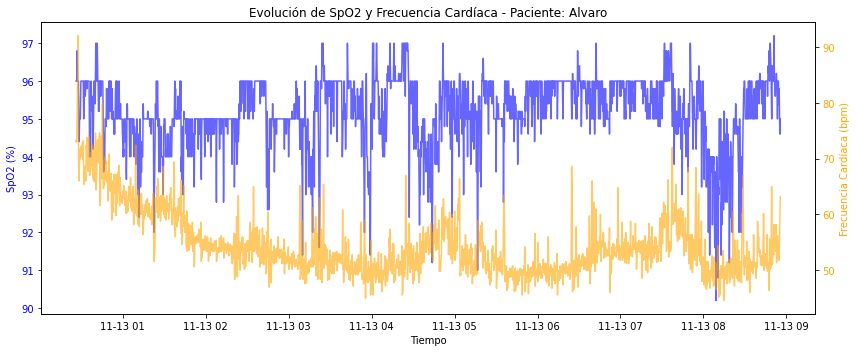

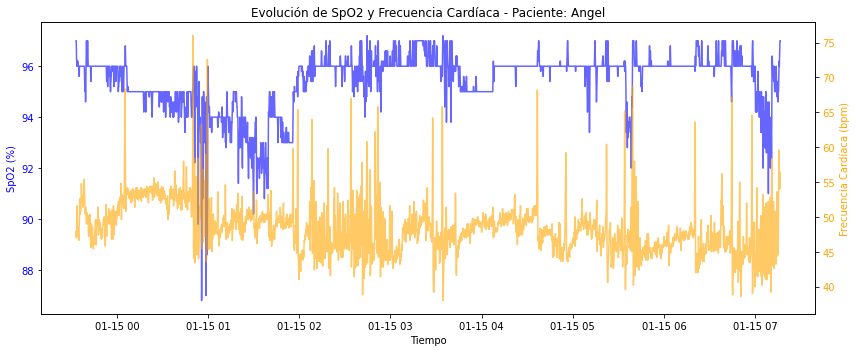

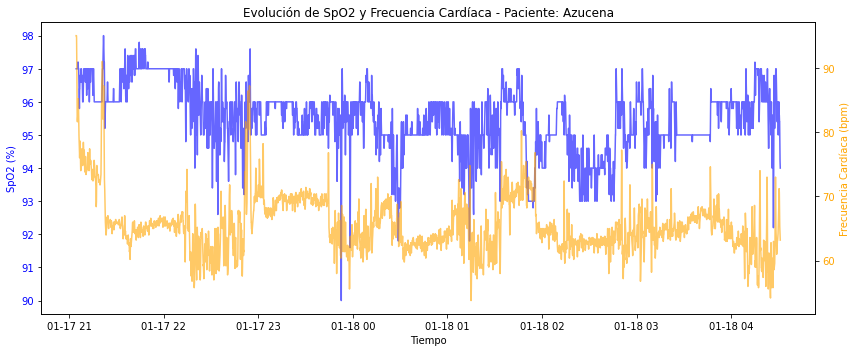

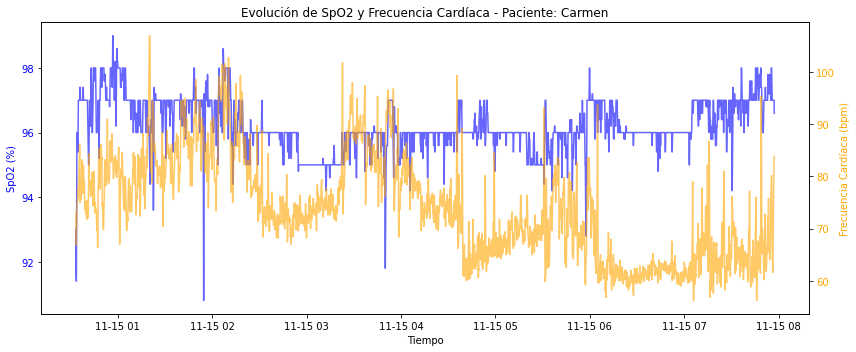

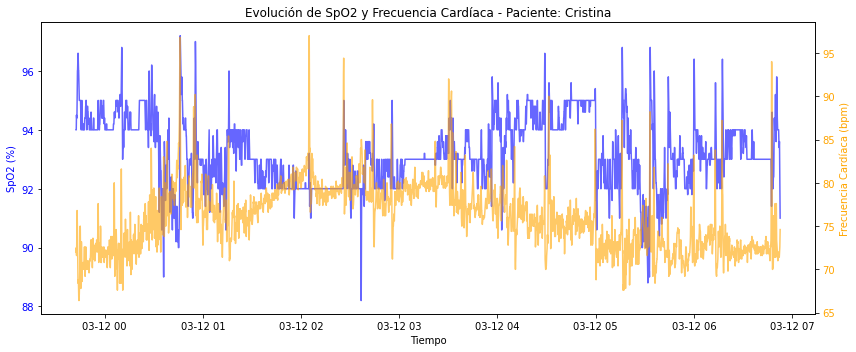

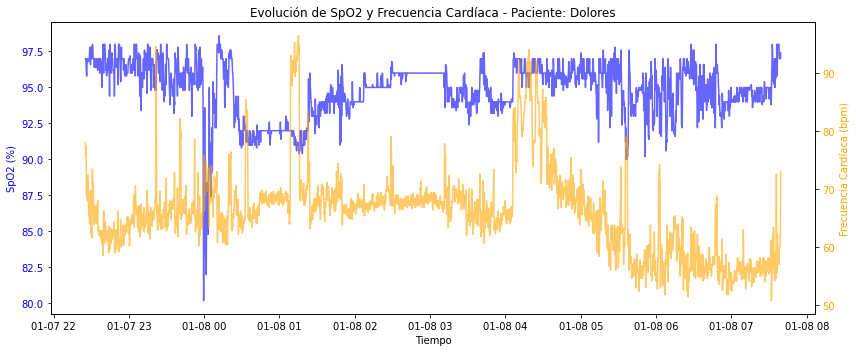

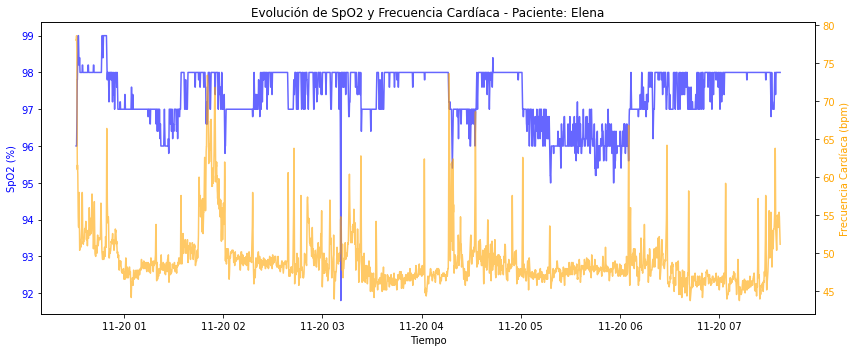

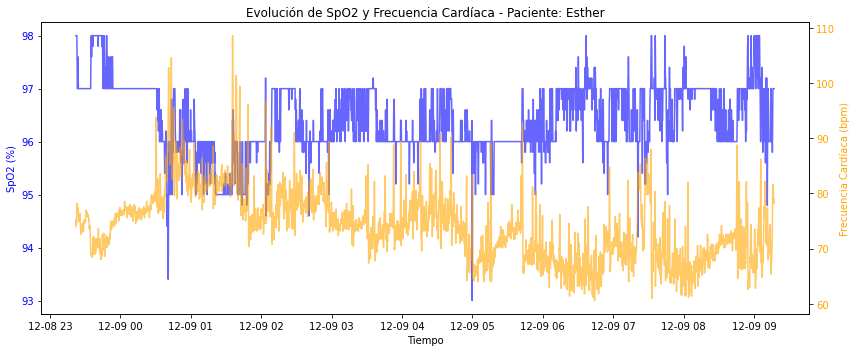

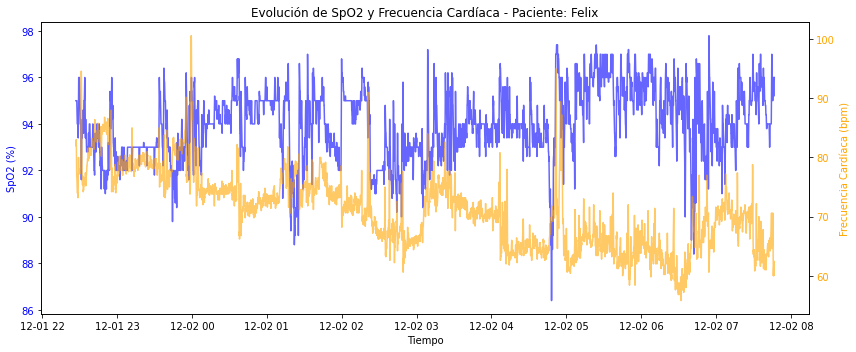

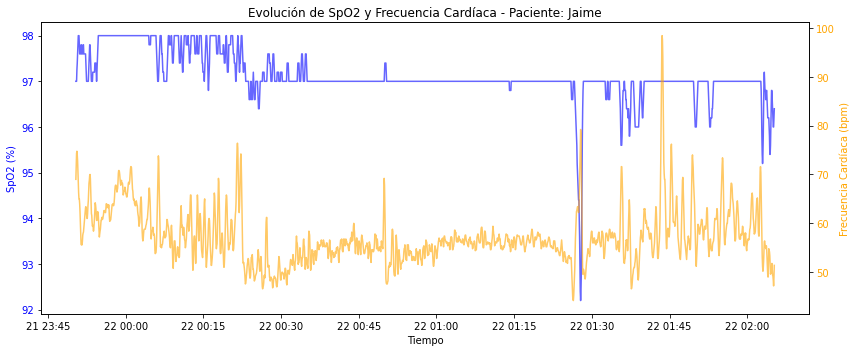

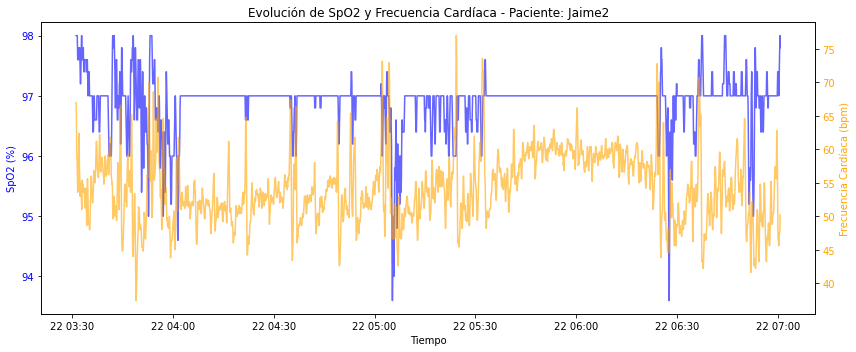

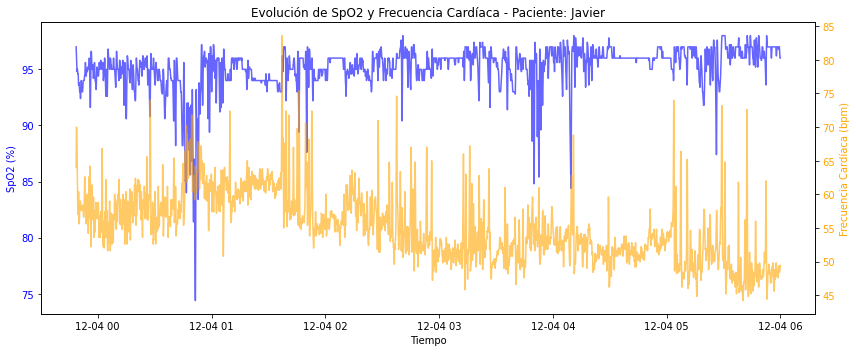

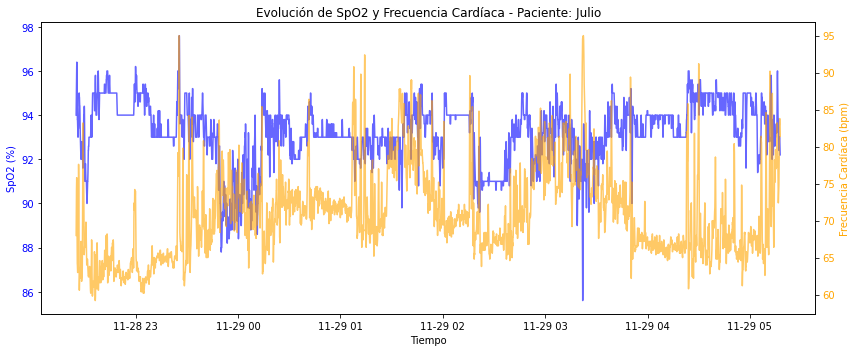

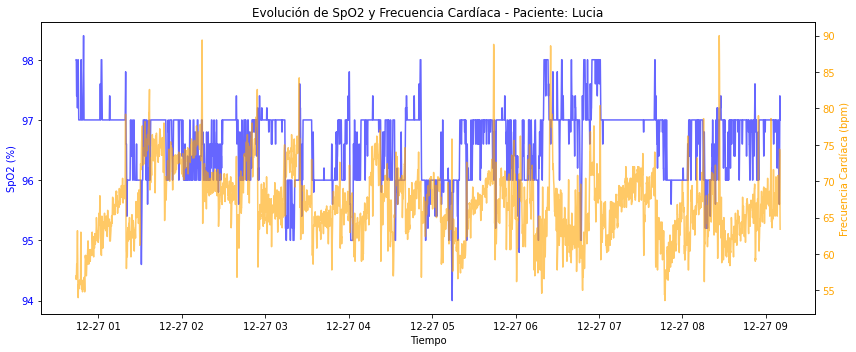

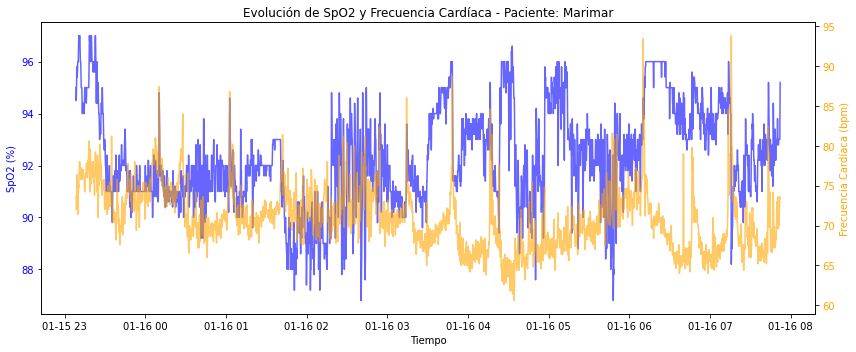

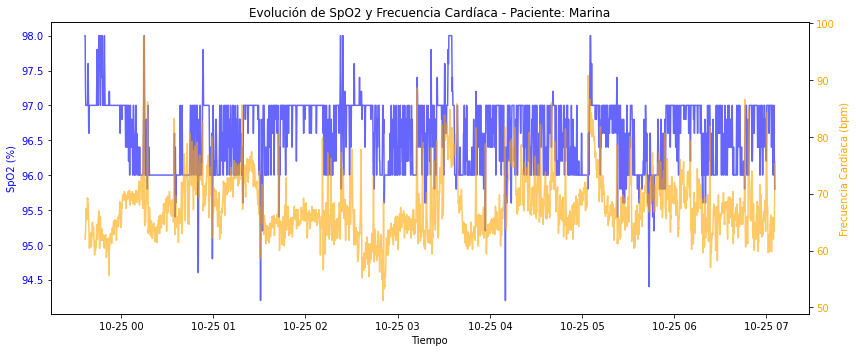

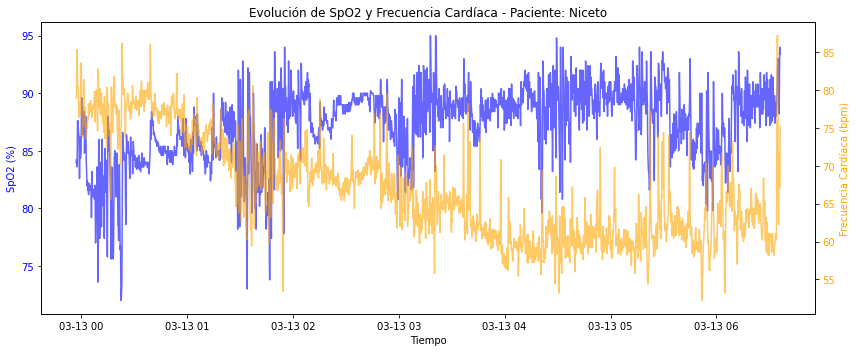

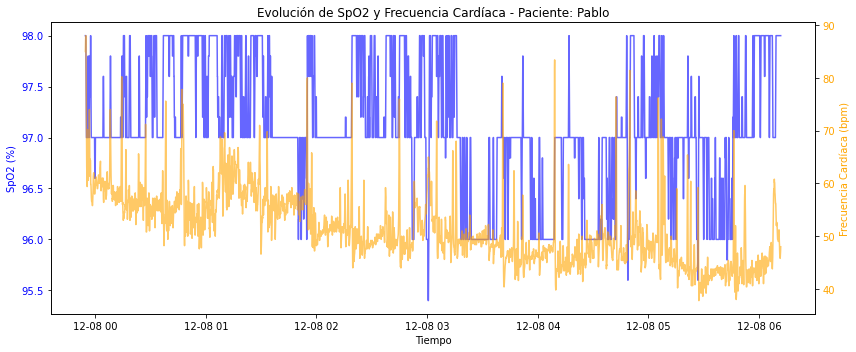

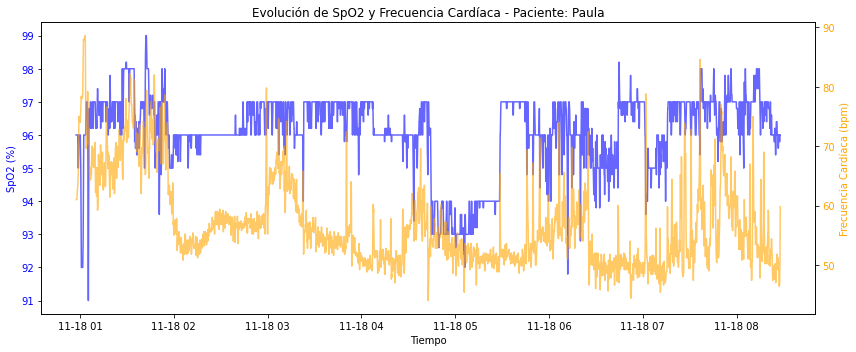

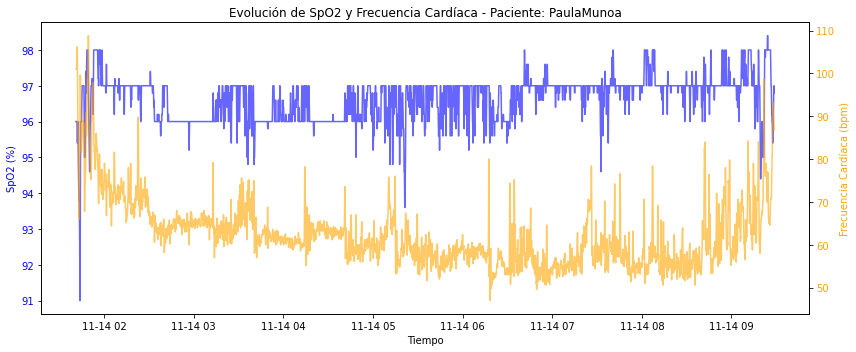

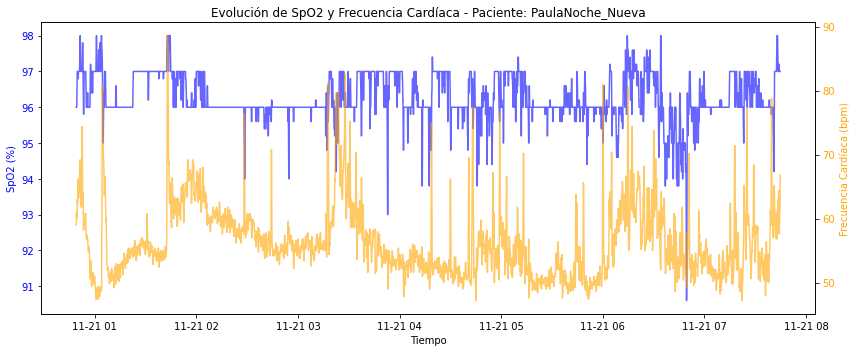

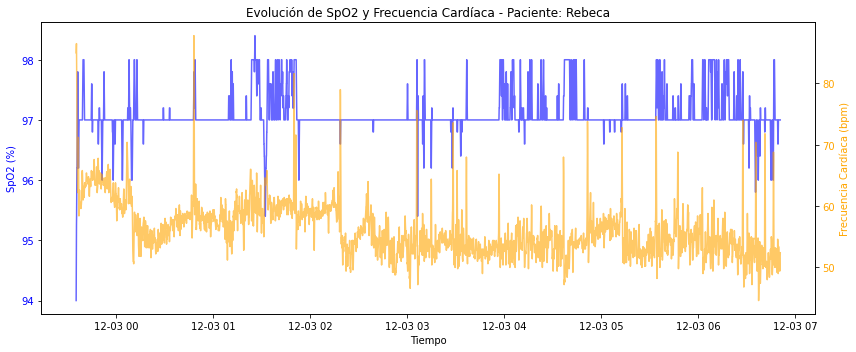

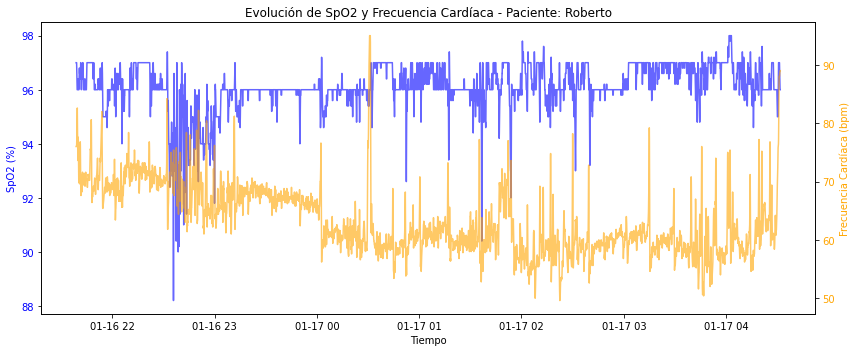

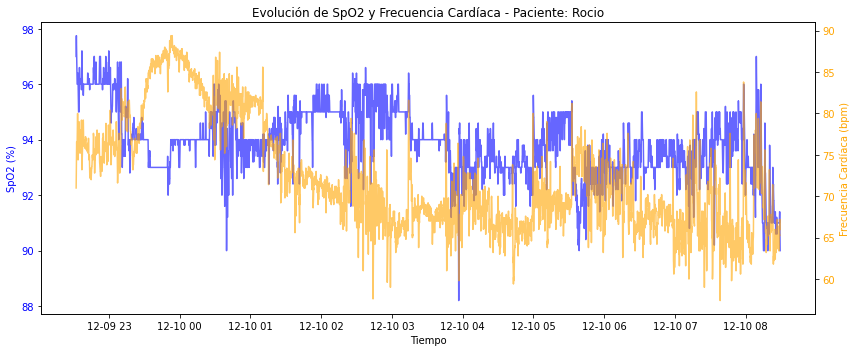

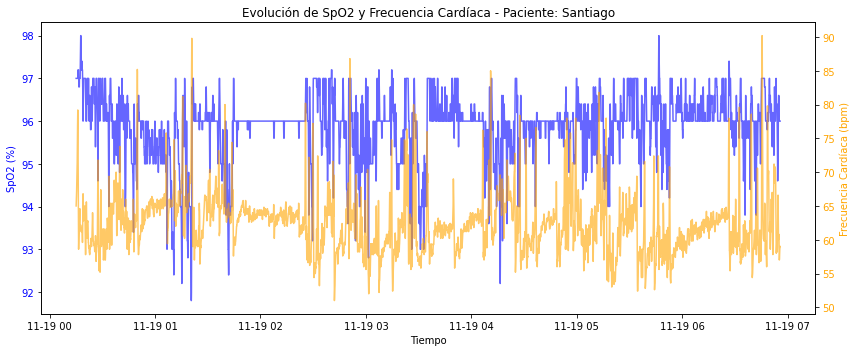

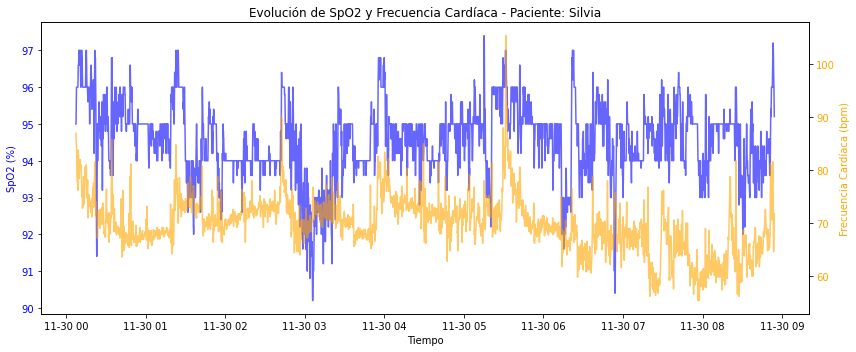

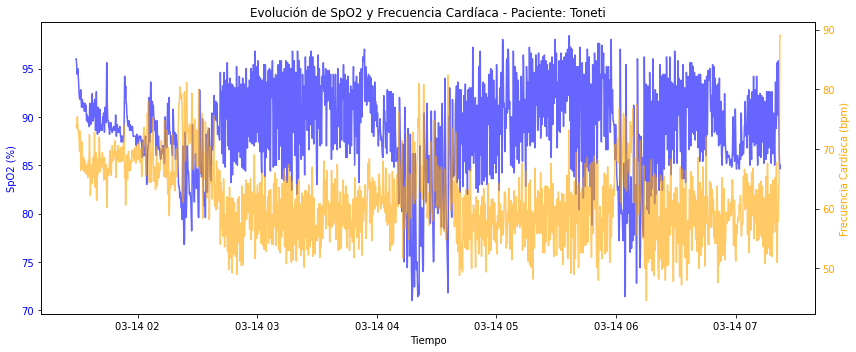

In [123]:
# Asegurar que los datos estén ordenados por paciente y tiempo
df_o2ring = df_o2ring.sort_values(by=["Paciente_ID", "Time"])

# Filtrar valores extremos si los hubiera
df_o2ring = df_o2ring[(df_o2ring['SpO2'] >= 70) & (df_o2ring['Frec_Cardiaca'] <= 200)]

# Crear gráficos por paciente
pacientes = df_o2ring["Paciente_ID"].unique()

for paciente_id in pacientes:
    datos_paciente = df_o2ring[df_o2ring["Paciente_ID"] == paciente_id].copy()
    
    # Suavizar los datos con media móvil
    datos_paciente["SpO2_suavizado"] = datos_paciente["SpO2"].rolling(window=5, min_periods=1).mean()
    datos_paciente["Frec_Cardiaca_suavizado"] = datos_paciente["Frec_Cardiaca"].rolling(window=5, min_periods=1).mean()
    
    # Graficar
    fig, ax1 = plt.subplots(figsize=(12, 5))

    ax1.set_xlabel("Tiempo")
    ax1.set_ylabel("SpO2 (%)", color="blue")
    ax1.plot(datos_paciente["Time"], datos_paciente["SpO2_suavizado"], label="SpO2", color="blue", alpha=0.6)
    ax1.tick_params(axis="y", labelcolor="blue")

    ax2 = ax1.twinx()
    ax2.set_ylabel("Frecuencia Cardíaca (bpm)", color="orange")
    ax2.plot(datos_paciente["Time"], datos_paciente["Frec_Cardiaca_suavizado"], label="Frecuencia Cardíaca", color="orange", alpha=0.6)
    ax2.tick_params(axis="y", labelcolor="orange")

    plt.title(f"Evolución de SpO2 y Frecuencia Cardíaca - Paciente: {paciente_id}")
    fig.tight_layout()
    plt.show()

#### ANÁLISIS ESTADÍSTICO INICIAL

Estadísticas Descriptivas:
                 SpO2  Frec_Cardiaca
count  178072.000000  178072.000000
mean       94.970922      63.876589
std         2.760447      10.168473
min        70.000000      36.000000
25%        94.000000      56.000000
50%        96.000000      64.000000
75%        97.000000      71.000000
max        99.000000     113.000000


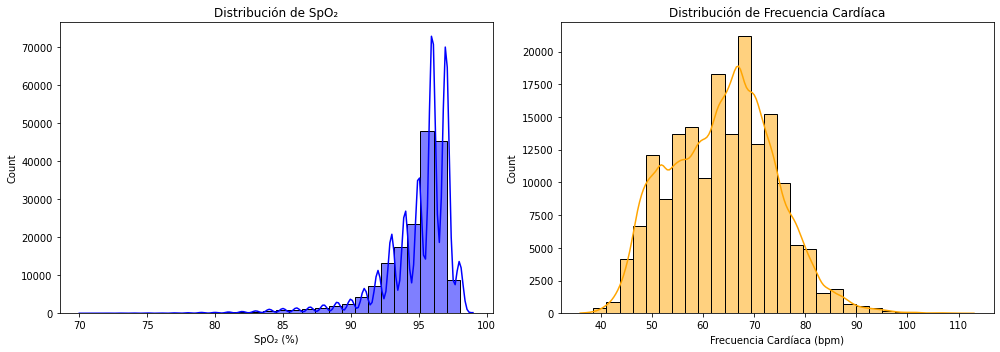

In [124]:
# Calcular estadísticas básicas
estadisticas = df_o2ring[['SpO2', 'Frec_Cardiaca']].describe()
print("Estadísticas Descriptivas:\n", estadisticas)

# Histogramas para visualizar distribuciones
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df_o2ring['SpO2'], bins=30, kde=True, ax=axes[0], color="blue")
axes[0].set_title("Distribución de SpO₂")
axes[0].set_xlabel("SpO₂ (%)")

sns.histplot(df_o2ring['Frec_Cardiaca'], bins=30, kde=True, ax=axes[1], color="orange")
axes[1].set_title("Distribución de Frecuencia Cardíaca")
axes[1].set_xlabel("Frecuencia Cardíaca (bpm)")

plt.tight_layout()
plt.show()

La saturación de oxígeno se encuentra entre el 73 y el 99%, con una media de 95.53. 

La frecuencia cardíaca entre  y 113 pulsaciones por minuto, con una media de  63.35.

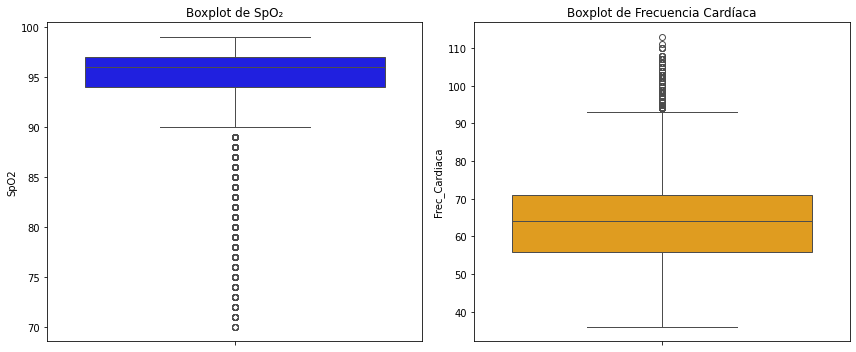

In [125]:
# Boxplots para detectar valores atípicos
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.boxplot(y=df_o2ring['SpO2'], ax=axes[0], color="blue")
axes[0].set_title("Boxplot de SpO₂")

sns.boxplot(y=df_o2ring['Frec_Cardiaca'], ax=axes[1], color="orange")
axes[1].set_title("Boxplot de Frecuencia Cardíaca")

plt.tight_layout()
plt.show()

SpO₂: Se observan valores atípicos por debajo de 90%.

Frecuencia Cardíaca: Muchos valores atípicos por encima de 100 bpm y por debajo de 50 bpm.

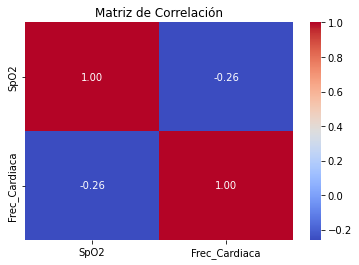

In [126]:
# Matriz de correlación
plt.figure(figsize=(6, 4))
sns.heatmap(df_o2ring[['SpO2', 'Frec_Cardiaca']].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Matriz de Correlación")
plt.show()

Existe una correlación negativa moderada entre la saturación y la frecuecnia cardíaca, de un -0.31. 

Esto quiere decir que cuando la saturación disminuye, la frecuecnía cardíaca tiende a subir. Esto tiene sentido fisiológico puesto que el corazón puede compensar una menor oxigenación aumentando la frecuencia cardíaca.

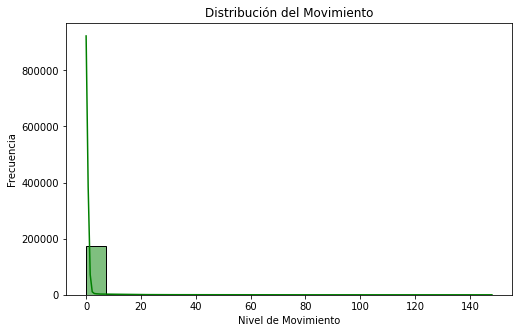

In [127]:
# DISTRIBUCION DEL MOVIMIENTO
plt.figure(figsize=(8, 5))
sns.histplot(df_o2ring["Movimiento"], bins=20, kde=True, color="green")
plt.title("Distribución del Movimiento")
plt.xlabel("Nivel de Movimiento")
plt.ylabel("Frecuencia")
plt.show()


La mayoría de los valores de "Movimiento" están concentrados en valores muy bajos, cercanos a 0.

Existen ciertos valores mucho más altos (hasta 140), pero son muy raros.

<ipython-input-128-f294c4b1906a>:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=df_o2ring["Movimiento"], y=df_o2ring["SpO2"], palette="Blues")
<ipython-input-128-f294c4b1906a>:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=df_o2ring["Movimiento"], y=df_o2ring["Frec_Cardiaca"], palette="Oranges")


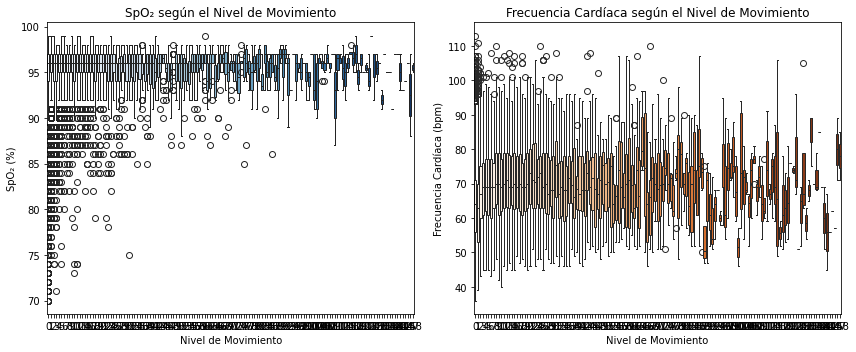

In [128]:
# RELACION ENTRE EL MOVIMIENTO Y OTRAS VARIABLES
plt.figure(figsize=(12, 5))

# Boxplot de SpO2 por niveles de movimiento
plt.subplot(1, 2, 1)
sns.boxplot(x=df_o2ring["Movimiento"], y=df_o2ring["SpO2"], palette="Blues")
plt.title("SpO₂ según el Nivel de Movimiento")
plt.xlabel("Nivel de Movimiento")
plt.ylabel("SpO₂ (%)")

# Boxplot de Frecuencia Cardíaca por niveles de movimiento
plt.subplot(1, 2, 2)
sns.boxplot(x=df_o2ring["Movimiento"], y=df_o2ring["Frec_Cardiaca"], palette="Oranges")
plt.title("Frecuencia Cardíaca según el Nivel de Movimiento")
plt.xlabel("Nivel de Movimiento")
plt.ylabel("Frecuencia Cardíaca (bpm)")

plt.tight_layout()
plt.show()

SpO2 vs Movimiento (Izquierda): 
- La saturación de oxígeno (SpO2) tiende a mantenerse estable alrededor del 95-100%, sin importar el nivel de movimiento.
- Sin embargo, hay algunos valores más bajos cuando hay movimiento, lo que podría indicar eventos de desaturación relacionados con actividad.


Frecuencia Cardíaca vs Movimiento (Derecha): 
- La frecuencia cardíaca aumenta con el movimiento, lo que es esperable.
- Hay mucha variabilidad en los valores cuando el movimiento es mayor, lo que indica que algunos pacientes pueden tener una respuesta cardíaca más fuerte que otros.


CONCLUSIONES:

- La relación entre movimiento y SpO2 es débil, pero puede haber eventos de desaturación en movimientos altos.
- La frecuencia cardíaca sí está afectada por el movimiento, aumentando conforme el movimiento es mayor.

#### DETECCIÓN DE VALORES ATÍPICOS

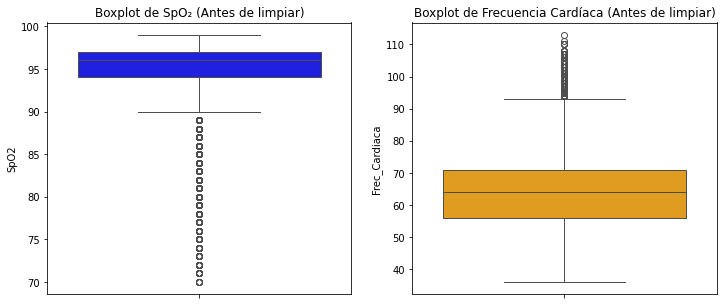

In [129]:
# Comparar los datos originales con los valores atípicos detectados
plt.figure(figsize=(12, 5))

# Boxplot antes de eliminar valores atípicos
plt.subplot(1, 2, 1)
sns.boxplot(y=df_o2ring['SpO2'], color="blue")
plt.title("Boxplot de SpO₂ (Antes de limpiar)")

plt.subplot(1, 2, 2)
sns.boxplot(y=df_o2ring['Frec_Cardiaca'], color="orange")
plt.title("Boxplot de Frecuencia Cardíaca (Antes de limpiar)")

plt.show()


In [130]:
print(df_o2ring.head())  # Ver las primeras filas
print(df_o2ring.columns)  # Ver los nombres de las columnas
print(df_o2ring.info())  # Ver información general del DataFrame


                 Time  SpO2  Frec_Cardiaca  Movimiento Paciente_ID
0 2024-11-13 00:26:18    96             73           0      Alvaro
1 2024-11-13 00:26:22    96             73           1      Alvaro
2 2024-11-13 00:26:26    96             74           0      Alvaro
3 2024-11-13 00:26:30    96             73           1      Alvaro
4 2024-11-13 00:26:34    96             72           9      Alvaro
Index(['Time', 'SpO2', 'Frec_Cardiaca', 'Movimiento', 'Paciente_ID'], dtype='object')
<class 'pandas.core.frame.DataFrame'>
Int64Index: 178072 entries, 0 to 178143
Data columns (total 5 columns):
 #   Column         Non-Null Count   Dtype         
---  ------         --------------   -----         
 0   Time           178072 non-null  datetime64[ns]
 1   SpO2           178072 non-null  int64         
 2   Frec_Cardiaca  178072 non-null  int64         
 3   Movimiento     178072 non-null  int64         
 4   Paciente_ID    178072 non-null  object        
dtypes: datetime64[ns](1), int64(3), o

##### A) MÉTODO DEL RANGO INTERCUARTÍLICO (IQR)

El IQR es una de las maneras más comunes de identificar valores atípicos. La idea es calcular los cuartiles (Q1 y Q3) y luego encontrar cualquier valor que esté fuera del rango intercuartílico definido por:

    Límite Inferior = Q1 - 1.5 x IQR
    Límmite Superior = Q3 + 1.5 x IQR
     
Cualquier valor fuera de estos límites puede condirarse un valor atípico.

In [131]:
# Calcular los cuartiles y el IQR para SpO2 y Frecuencia Cardíaca
Q1_spo2 = df_o2ring['SpO2'].quantile(0.25)
Q3_spo2 = df_o2ring['SpO2'].quantile(0.75)
IQR_spo2 = Q3_spo2 - Q1_spo2

Q1_fc = df_o2ring['Frec_Cardiaca'].quantile(0.25)
Q3_fc = df_o2ring['Frec_Cardiaca'].quantile(0.75)
IQR_fc = Q3_fc - Q1_fc

# Detectar los valores atípicos
limite_inferior_spo2 = Q1_spo2 - 1.5 * IQR_spo2
limite_superior_spo2 = Q3_spo2 + 1.5 * IQR_spo2
valores_atipicos_spo2 = df_o2ring[(df_o2ring['SpO2'] < limite_inferior_spo2) | (df_o2ring['SpO2'] > limite_superior_spo2)]

limite_inferior_fc = Q1_fc - 1.5 * IQR_fc
limite_superior_fc = Q3_fc + 1.5 * IQR_fc
valores_atipicos_fc = df_o2ring[(df_o2ring['Frec_Cardiaca'] < limite_inferior_fc) | (df_o2ring['Frec_Cardiaca'] > limite_superior_fc)]

# Verificar los valores atípicos
print(valores_atipicos_spo2)
print(valores_atipicos_fc)


                      Time  SpO2  Frec_Cardiaca  Movimiento Paciente_ID
6939   2024-11-13 08:08:54    89             50           0      Alvaro
8846   2025-01-15 00:53:26    88             50           0       Angel
8847   2025-01-15 00:53:30    89             43           0       Angel
8877   2025-01-15 00:55:30    89             65           1       Angel
8878   2025-01-15 00:55:34    87             70           0       Angel
...                    ...   ...            ...         ...         ...
178139 2025-03-14 07:22:08    85             89          38      Toneti
178140 2025-03-14 07:22:12    85             89           9      Toneti
178141 2025-03-14 07:22:16    85             89          15      Toneti
178142 2025-03-14 07:22:20    85             89          17      Toneti
178143 2025-03-14 07:22:24    85             89           1      Toneti

[8266 rows x 5 columns]
                      Time  SpO2  Frec_Cardiaca  Movimiento Paciente_ID
17     2024-11-13 00:27:26    96       

##### B) MÉTODO Z-SCORE

In [132]:
from scipy.stats import zscore

# Calcular el Z-Score para SpO2 y Frecuencia Cardíaca
df_o2ring['z_spo2'] = zscore(df_o2ring['SpO2'])
df_o2ring['z_fc'] = zscore(df_o2ring['Frec_Cardiaca'])

# Valores atípicos según Z-Score
valores_atipicos_z_spo2 = df_o2ring[df_o2ring['z_spo2'].abs() > 3]
valores_atipicos_z_fc = df_o2ring[df_o2ring['z_fc'].abs() > 3]

print(valores_atipicos_z_spo2)
print(valores_atipicos_z_fc)


                      Time  SpO2  Frec_Cardiaca  Movimiento Paciente_ID  \
8879   2025-01-15 00:55:38    86             67           0       Angel   
8880   2025-01-15 00:55:42    85             51           0       Angel   
8922   2025-01-15 00:58:30    86             60           0       Angel   
8923   2025-01-15 00:58:34    85             48           0       Angel   
8936   2025-01-15 00:59:26    86             82           0       Angel   
...                    ...   ...            ...         ...         ...   
178139 2025-03-14 07:22:08    85             89          38      Toneti   
178140 2025-03-14 07:22:12    85             89           9      Toneti   
178141 2025-03-14 07:22:16    85             89          15      Toneti   
178142 2025-03-14 07:22:20    85             89          17      Toneti   
178143 2025-03-14 07:22:24    85             89           1      Toneti   

          z_spo2      z_fc  
8879   -3.249816  0.307167  
8880   -3.612078 -1.266328  
8922   -3.24

##### C) VISUALIZACIÓN ADICIONAL

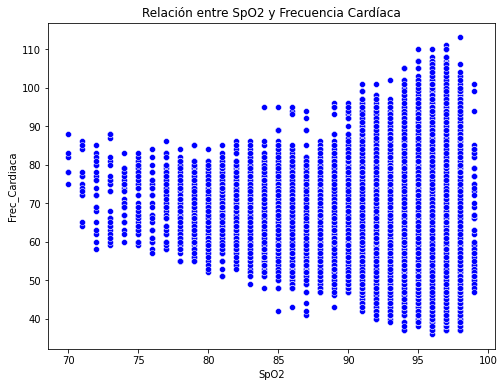

In [133]:
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df_o2ring, x='SpO2', y='Frec_Cardiaca', color='blue')
plt.title('Relación entre SpO2 y Frecuencia Cardíaca')
plt.show()


Los valores atípicos de saturación y frecuencia cardíaca pueden indicar eventos fisiológicos raros que deben ser analizados, especialmente en el presente trabajo puesto que cobran relación con eventos de apnea. Más tarde se abordarán

Para distinguir entre valores atípicos reales y posibles errores de medición, nos basaremos en la literatura:

1. SATURACIÓN

    - Valores de SpO2 entre **90 y 100%** son considerados **normales**, incluso si son atípicos según el IQR o Z-Score **no los eliminaremos**.
    - Valores de SpO2 por **debajo de 85%** pueden indicar **eventos importantes de desaturación**, de manera que **no los eliminamos ya que estudiaremos problemas respiratorios**.
    - Valores de SpO2 por **debajo de 70%** podrían indicar **errores de medición** o situaciones extremadamente graves (poco probables, veremos cuántas hay para considerar elimarlas). 
    
    
2. FRECUENCIA CARDÍACA

    - Valores de frecuencia cardíaca **entre 40 y 110 pulsaciones por minuto** pueden considerarse normales para los estados de sueño y vigilia.
    - Si existen valores **por debajo de 35 o por encima de 120**, podrían seer errores o eventos fisiológicos raros.

In [134]:
# SpO2 < 70% los eliminamos
print(df_o2ring[df_o2ring["SpO2"] < 70])  # Ver cuántos valores hay debajo de 70
df_o2ring = df_o2ring[df_o2ring["SpO2"] >= 70]  # Eliminar solo si hay muy pocos


Empty DataFrame
Columns: [Time, SpO2, Frec_Cardiaca, Movimiento, Paciente_ID, z_spo2, z_fc]
Index: []


In [135]:
# Frec_Cardiaca < 40 y Frec_Cardiaca > 120 los elminamos 
print(df_o2ring[(df_o2ring["Frec_Cardiaca"] < 40) | (df_o2ring["Frec_Cardiaca"] > 120)])
df_o2ring = df_o2ring[(df_o2ring["Frec_Cardiaca"] >= 40) & (df_o2ring["Frec_Cardiaca"] <= 120)]


                      Time  SpO2  Frec_Cardiaca  Movimiento Paciente_ID  \
8829   2025-01-15 00:52:18    96             37           0       Angel   
9837   2025-01-15 01:59:30    96             39           0       Angel   
9991   2025-01-15 02:09:46    97             37           0       Angel   
10384  2025-01-15 02:35:58    95             38           0       Angel   
10434  2025-01-15 02:39:18    96             37           0       Angel   
...                    ...   ...            ...         ...         ...   
116871 2024-12-08 05:48:30    97             39           0       Pablo   
116878 2024-12-08 05:48:58    98             39           0       Pablo   
116987 2024-12-08 05:56:14    97             39           1       Pablo   
117076 2024-12-08 06:02:10    98             39           1       Pablo   
117077 2024-12-08 06:02:14    98             39           1       Pablo   

          z_spo2      z_fc  
8829    0.372795 -2.643137  
9837    0.372795 -2.446450  
9991    0.73

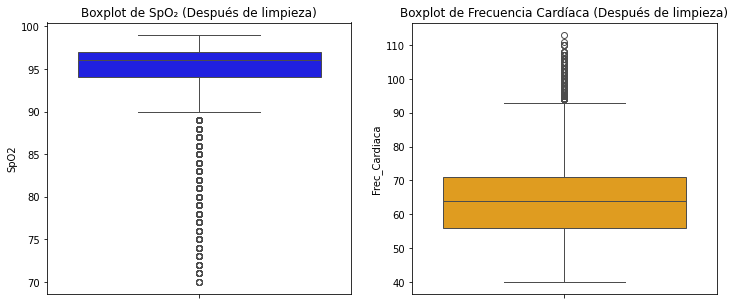

In [136]:
# Visualizaciones para comprobar que los datos tienen sentido
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.boxplot(y=df_o2ring['SpO2'], ax=axes[0], color="blue")
axes[0].set_title("Boxplot de SpO₂ (Después de limpieza)")

sns.boxplot(y=df_o2ring['Frec_Cardiaca'], ax=axes[1], color="orange")
axes[1].set_title("Boxplot de Frecuencia Cardíaca (Después de limpieza)")

plt.show()


In [137]:
display(lista_personas[['Paciente_ID', 'Peso (kg)', 'Altura (m)', 'IMC']].head(10))

,Paciente_ID,Peso (kg),Altura (m),IMC
1,Alvaro,78,1.75,25.469388
3,Carmen,66,1.63,24.840980
4,Paula,56,1.74,18.496499
6,Elena,53,1.60,20.703125
7,Jaime,115,1.78,36.295922
9,Ana,57,1.73,19.045073
10,Julio,93,1.83,27.770313
11,Silvia,53,1.58,21.230572
12,Felix,75,1.73,25.059307
13,Rebeca,54,1.63,20.324438


In [138]:
print("Tamaño antes de la limpieza:", df_o2ring.shape)

# Filtrado (usando los criterios que definimos antes)
df_o2ring_filtrado = df_o2ring[
    (df_o2ring['SpO2'] >= 70) &
    (df_o2ring['Frec_Cardiaca'] >= 40) &
    (df_o2ring['Frec_Cardiaca'] <= 120)
]

print("Tamaño después de la limpieza:", df_o2ring_filtrado.shape)


Tamaño antes de la limpieza: (177972, 7)
Tamaño después de la limpieza: (177972, 7)


In [139]:
print("Estadísticas antes de la limpieza:")
print(df_o2ring[['SpO2', 'Frec_Cardiaca']].describe())

print("Estadísticas después de la limpieza:")
print(df_o2ring_filtrado[['SpO2', 'Frec_Cardiaca']].describe())


Estadísticas antes de la limpieza:
                SpO2  Frec_Cardiaca
count  177972.000000  177972.000000
mean       94.970007      63.890921
std         2.760843      10.153315
min        70.000000      40.000000
25%        94.000000      56.000000
50%        96.000000      64.000000
75%        97.000000      71.000000
max        99.000000     113.000000
Estadísticas después de la limpieza:
                SpO2  Frec_Cardiaca
count  177972.000000  177972.000000
mean       94.970007      63.890921
std         2.760843      10.153315
min        70.000000      40.000000
25%        94.000000      56.000000
50%        96.000000      64.000000
75%        97.000000      71.000000
max        99.000000     113.000000


In [140]:
iqr_spo2_antes = df_o2ring['SpO2'].quantile(0.75) - df_o2ring['SpO2'].quantile(0.25)
iqr_fc_antes = df_o2ring['Frec_Cardiaca'].quantile(0.75) - df_o2ring['Frec_Cardiaca'].quantile(0.25)

iqr_spo2_despues = df_o2ring_filtrado['SpO2'].quantile(0.75) - df_o2ring_filtrado['SpO2'].quantile(0.25)
iqr_fc_despues = df_o2ring_filtrado['Frec_Cardiaca'].quantile(0.75) - df_o2ring_filtrado['Frec_Cardiaca'].quantile(0.25)

print(f"IQR SpO2 antes: {iqr_spo2_antes}, después: {iqr_spo2_despues}")
print(f"IQR Frecuencia Cardíaca antes: {iqr_fc_antes}, después: {iqr_fc_despues}")


IQR SpO2 antes: 3.0, después: 3.0
IQR Frecuencia Cardíaca antes: 15.0, después: 15.0


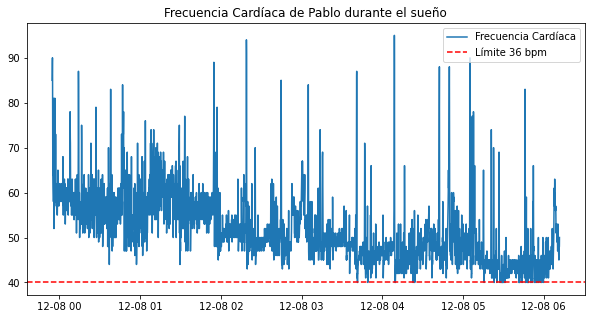

In [141]:
# PABLO TIENE UNA FRECUENCIA MUY MAJA --> BUENA CONDICION FISICA
df_pablo = df_o2ring[df_o2ring["Paciente_ID"] == "Pablo"]
plt.figure(figsize=(10, 5))
plt.plot(df_pablo["Time"], df_pablo["Frec_Cardiaca"], label="Frecuencia Cardíaca")
plt.axhline(y=40, color='r', linestyle='--', label="Límite 36 bpm")
plt.legend()
plt.title("Frecuencia Cardíaca de Pablo durante el sueño")
plt.show()


#### ANÁLISIS INICIAL DEL TEST DE PITTSBURGH


<ipython-input-142-e1a67fdc67ad>:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=test_pittsburgh["Calidad_Sueño"], palette="viridis")


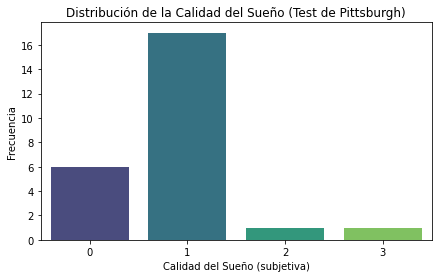

In [142]:
# ANÁLISIS DE LA CALIDAD SUBJETIVA DEL SUEÑO
# Contar frecuencia de cada categoría de calidad del sueño
plt.figure(figsize=(7, 4))
sns.countplot(x=test_pittsburgh["Calidad_Sueño"], palette="viridis")
plt.title("Distribución de la Calidad del Sueño (Test de Pittsburgh)")
plt.xlabel("Calidad del Sueño (subjetiva)")
plt.ylabel("Frecuencia")
plt.show()

<ipython-input-143-13940ecf9f42>:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x=test_pittsburgh["Calidad_Sueño"], palette="viridis")


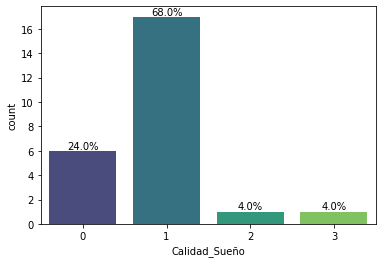

In [143]:
ax = sns.countplot(x=test_pittsburgh["Calidad_Sueño"], palette="viridis")
for p in ax.patches:
    ax.annotate(f'{p.get_height() / len(test_pittsburgh) * 100:.1f}%',  
                (p.get_x() + p.get_width() / 2., p.get_height()),  
                ha='center', va='bottom', fontsize=10)

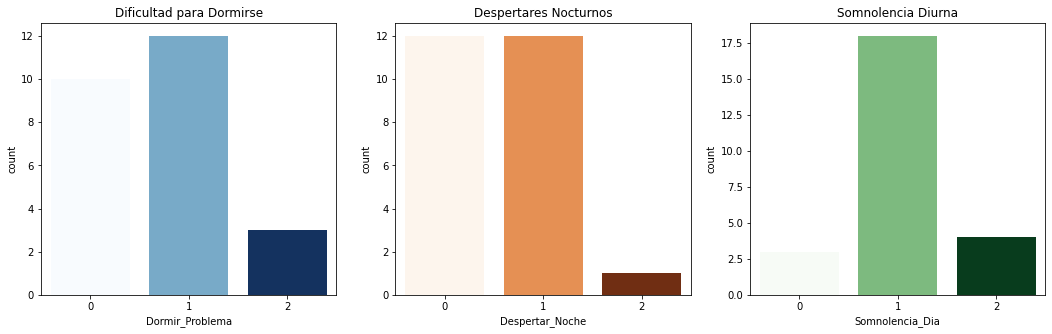

In [144]:
# DISTRIBUCIÓN DE LAS RESPUESTAS EN PREGUNTAS CLAVE
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Problemas para quedarse dormido
sns.countplot(x=test_pittsburgh["Dormir_Problema"], hue=test_pittsburgh["Dormir_Problema"], ax=axes[0], palette="Blues", legend=False)
axes[0].set_title("Dificultad para Dormirse")

# Despertares nocturnos
sns.countplot(x=test_pittsburgh["Despertar_Noche"],hue=test_pittsburgh["Despertar_Noche"], ax=axes[1], palette="Oranges", legend=False)
axes[1].set_title("Despertares Nocturnos")

# Somnolencia diurna
sns.countplot(x=test_pittsburgh["Somnolencia_Dia"], hue=test_pittsburgh["Somnolencia_Dia"], ax=axes[2], palette="Greens", legend=False)
axes[2].set_title("Somnolencia Diurna")

plt.show()


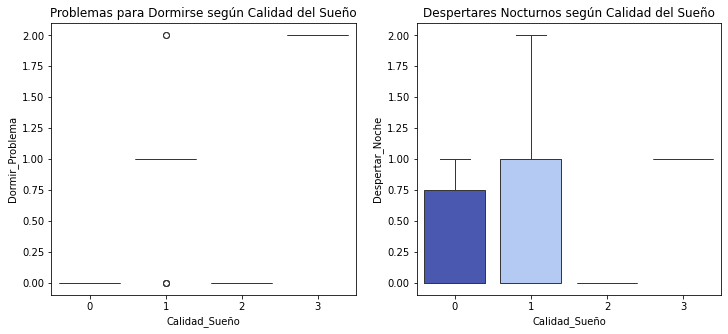

In [145]:
# RELACIÓN ENTRE LA CALIDAD DEL SUEÑO Y RESPUESTAS ESPECÍFICAS
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Relación entre calidad del sueño y problemas para dormirse
sns.boxplot(x=test_pittsburgh["Calidad_Sueño"], y=test_pittsburgh["Dormir_Problema"], hue=test_pittsburgh["Calidad_Sueño"], ax=axes[0], palette="coolwarm", legend=False)
axes[0].set_title("Problemas para Dormirse según Calidad del Sueño")

# Relación entre calidad del sueño y despertares nocturnos
sns.boxplot(x=test_pittsburgh["Calidad_Sueño"], y=test_pittsburgh["Despertar_Noche"], hue=test_pittsburgh["Calidad_Sueño"], ax=axes[1], palette="coolwarm", legend=False)
axes[1].set_title("Despertares Nocturnos según Calidad del Sueño")

plt.show()


#### ANÁLISIS EXCEL LISTA DE PERSONAS
Distribucion de las edades y género:
- Histograma de edades para observar la distribución de los datos.
- Gráfico de barras de género para ver si hay balance entre hiombres y mujeres.

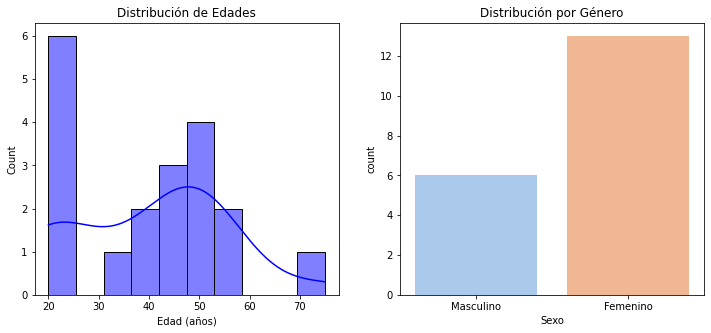

In [146]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.histplot(lista_personas["Edad (años)"], bins=10, kde=True, color="blue")
plt.title("Distribución de Edades")

plt.subplot(1, 2, 2)
sns.countplot(x=lista_personas["Sexo"], hue=lista_personas["Sexo"], palette="pastel", legend=False)
plt.title("Distribución por Género")

plt.show()

REVISIÓN DE DATOS FALTANTES

In [147]:
# comprobar si hay valores nulos
print(lista_personas.isnull().sum())

Paciente_ID             0
Edad (años)             0
Peso (kg)               0
Altura (m)              0
IMC                     0
Sexo                    0
Fecha prueba 1          0
Sexo_Codificado         0
Calidad_Sueño_Subjet    0
dtype: int64


COMPROBAR SI TODOS LOS DATASETS TIENEN EL MISMO Nº DE PACIENTES

In [148]:
print("Pacientes en la lista de personas:", lista_personas["Paciente_ID"].nunique())
print("Pacientes en O2Ring:", df_o2ring["Paciente_ID"].nunique())
print("Pacientes en Test de Pittsburgh:", test_pittsburgh["ID_Paciente"].nunique())

Pacientes en la lista de personas: 19
Pacientes en O2Ring: 27
Pacientes en Test de Pittsburgh: 25


## 4. EXTRACCIÓN DE CARACTERÍSTICAS
 Nos enfocaremos en **tres áreas principales**:

#### A) ESTADÍSTICAS BÁSICAS POR PACIENTE

Para cada pacienre, calculamos:
- Media, mediana y desviación estándar de SpO2 y Frec_Cardiaca.
- Mínimo y máximo de SpO2 y Frec_Cardiaca.
- Porcentaje de tiempo con SpO2 < 90% (posibles desaturaciones).
- Porcentaje de tiempo con Frec_Cardiaca < 50 bpm o > 100 bpm

In [149]:
# Agrupar por paciente y calcular estadísticas básicas
features = df_o2ring.groupby("Paciente_ID").agg(
    SpO2_mean=("SpO2", "mean"),
    SpO2_median=("SpO2", "median"),
    SpO2_std=("SpO2", "std"),
    SpO2_min=("SpO2", "min"),
    SpO2_max=("SpO2", "max"),
    FC_mean=("Frec_Cardiaca", "mean"),
    FC_median=("Frec_Cardiaca", "median"),
    FC_std=("Frec_Cardiaca", "std"),
    FC_min=("Frec_Cardiaca", "min"),
    FC_max=("Frec_Cardiaca", "max"),
    
    Porc_Desat=("SpO2", lambda x: (x < 90).mean()),  
    Porc_Bradycardia=("Frec_Cardiaca", lambda x: (x < 50).mean()),  
    Porc_Taqui=("Frec_Cardiaca", lambda x: (x > 100).mean())
).reset_index()

display(features.head(30))


,Paciente_ID,SpO2_mean,SpO2_median,SpO2_std,SpO2_min,SpO2_max,FC_mean,FC_median,FC_std,FC_min,FC_max,Porc_Desat,Porc_Bradycardia,Porc_Taqui
0,Alvaro,95.172644,95.0,1.004068,89,98,54.524738,53.0,5.918163,41,95,0.000131,0.150262,0.000000
1,Angel,95.419724,96.0,1.198546,85,98,48.495577,48.0,4.304409,40,84,0.002030,0.666715,0.000000
2,Azucena,95.495149,96.0,1.052276,89,98,65.577997,65.0,4.711567,53,95,0.000299,0.000000,0.000000
3,Carmen,96.195554,96.0,0.849797,88,99,74.044908,73.0,10.059083,51,110,0.000300,0.000000,0.006308
4,Cristina,93.197118,93.0,1.218990,86,98,76.078103,76.0,4.092177,65,103,0.003099,0.000000,0.001085
5,Dolores,94.839312,95.0,1.953796,79,99,65.953298,66.0,7.458984,47,99,0.009389,0.000481,0.000000
6,Elena,97.372144,98.0,0.771523,89,99,49.151800,48.0,4.050680,41,83,0.000156,0.713928,0.000000
7,Esther,96.404727,96.0,0.703272,92,98,74.187633,74.0,6.598287,56,113,0.000000,0.000000,0.003361
8,Felix,93.975703,94.0,1.572358,86,98,71.097785,71.0,6.528599,52,101,0.007265,0.000000,0.000476
9,Jaime,97.114625,97.0,0.583768,91,98,57.198123,56.0,6.434412,42,105,0.000000,0.071146,0.000988


In [150]:
import numpy as np
import pandas as pd

# Función para calcular ODI por paciente
def calcular_odi(df):
    # Ordenar por tiempo para cada paciente
    df = df.sort_values('Time')
    
    # Calcular la diferencia entre valores consecutivos
    diff_spo2 = df['SpO2'].diff()
    
    # Detectar eventos de desaturación ≥4%
    eventos_desaturacion = diff_spo2[diff_spo2 <= -4].count()
    
    # Duración de la grabación en horas
    duracion_segundos = (df['Time'].max() - df['Time'].min()).total_seconds()
    duracion_horas = duracion_segundos / 3600 if duracion_segundos > 0 else 1  # Evitar división por cero
    
    # ODI es eventos por hora
    odi = eventos_desaturacion / duracion_horas
    
    return odi

# Agrupación por paciente para calcular CT90 y ODI
features = df_o2ring.groupby("Paciente_ID").agg(
    SpO2_mean=("SpO2", "mean"),
    SpO2_median=("SpO2", "median"),
    SpO2_std=("SpO2", "std"),
    SpO2_min=("SpO2", "min"),
    SpO2_max=("SpO2", "max"),
    
    FC_mean=("Frec_Cardiaca", "mean"),
    FC_median=("Frec_Cardiaca", "median"),
    FC_std=("Frec_Cardiaca", "std"),
    FC_min=("Frec_Cardiaca", "min"),
    FC_max=("Frec_Cardiaca", "max"),
    
    CT90=("SpO2", lambda x: (x < 90).mean()),  # CT90 es igual a Porc_Desat
    
    Porc_Bradycardia=("Frec_Cardiaca", lambda x: (x < 50).mean()),
    Porc_Taqui=("Frec_Cardiaca", lambda x: (x > 100).mean()),
).reset_index()

# Calculamos ODI por paciente (recorremos cada paciente)
odi_list = []
for paciente_id, df_paciente in df_o2ring.groupby('Paciente_ID'):
    odi_valor = calcular_odi(df_paciente)
    odi_list.append({'Paciente_ID': paciente_id, 'ODI': odi_valor})

# Convertir a DataFrame y unir con el resto de features
df_odi = pd.DataFrame(odi_list)

# Merge de ODI con el dataframe features
features = features.merge(df_odi, on='Paciente_ID', how='left')

# Mostrar resultados
display(features.head(10))


,Paciente_ID,SpO2_mean,SpO2_median,SpO2_std,SpO2_min,SpO2_max,FC_mean,FC_median,FC_std,FC_min,FC_max,CT90,Porc_Bradycardia,Porc_Taqui,ODI
0,Alvaro,95.172644,95.0,1.004068,89,98,54.524738,53.0,5.918163,41,95,0.000131,0.150262,0.000000,0.000000
1,Angel,95.419724,96.0,1.198546,85,98,48.495577,48.0,4.304409,40,84,0.002030,0.666715,0.000000,0.000000
2,Azucena,95.495149,96.0,1.052276,89,98,65.577997,65.0,4.711567,53,95,0.000299,0.000000,0.000000,0.000000
3,Carmen,96.195554,96.0,0.849797,88,99,74.044908,73.0,10.059083,51,110,0.000300,0.000000,0.006308,0.135196
4,Cristina,93.197118,93.0,1.218990,86,98,76.078103,76.0,4.092177,65,103,0.003099,0.000000,0.001085,0.000000
5,Dolores,94.839312,95.0,1.953796,79,99,65.953298,66.0,7.458984,47,99,0.009389,0.000481,0.000000,0.324949
6,Elena,97.372144,98.0,0.771523,89,99,49.151800,48.0,4.050680,41,83,0.000156,0.713928,0.000000,0.140867
7,Esther,96.404727,96.0,0.703272,92,98,74.187633,74.0,6.598287,56,113,0.000000,0.000000,0.003361,0.000000
8,Felix,93.975703,94.0,1.572358,86,98,71.097785,71.0,6.528599,52,101,0.007265,0.000000,0.000476,0.107207
9,Jaime,97.114625,97.0,0.583768,91,98,57.198123,56.0,6.434412,42,105,0.000000,0.071146,0.000988,0.000000


In [151]:
# COMPROBAMOS ALGUNAS VARIABLES DE ANTES DE OTRA MANERA SIMILAR
caracteristicas_pacientes = []

# Iteramos sobre cada paciente único
for paciente in df_o2ring["Paciente_ID"].unique():
    
    datos_paciente = df_o2ring[df_o2ring["Paciente_ID"] == paciente]
    
    # Duración de la medición en horas
    tiempo_total_horas = (datos_paciente["Time"].max() - datos_paciente["Time"].min()).total_seconds() / 3600
    
    # CT90
    tiempo_bajo_90 = datos_paciente[datos_paciente["SpO2"] < 90].shape[0]
    porcentaje_tiempo_bajo_90 = (tiempo_bajo_90 / datos_paciente.shape[0]) * 100
    
    # ODI: caídas ≥4% desde la saturación basal (simplificado)
    dif_spo2 = datos_paciente["SpO2"].diff()
    desaturaciones = dif_spo2[ dif_spo2 <= -4 ].count()
    odi = desaturaciones / tiempo_total_horas  # eventos/hora
    
    # Media y desviación de SpO2 y Frec_Cardiaca
    spo2_media = datos_paciente["SpO2"].mean()
    spo2_std = datos_paciente["SpO2"].std()
    
    fc_media = datos_paciente["Frec_Cardiaca"].mean()
    fc_std = datos_paciente["Frec_Cardiaca"].std()
    
    # Movimiento total y media
    movimiento_total = datos_paciente["Movimiento"].sum()
    movimiento_medio = datos_paciente["Movimiento"].mean()
    
    # Guardar resultados
    caracteristicas_pacientes.append({
        "Paciente_ID": paciente,
        "CT90": porcentaje_tiempo_bajo_90,
        "ODI": odi,
        "SpO2_Media": spo2_media,
        "SpO2_Std": spo2_std,
        "Frec_Cardiaca_Media": fc_media,
        "Frec_Cardiaca_Std": fc_std,
        "Movimiento_Total": movimiento_total,
        "Movimiento_Medio": movimiento_medio
    })

# Convertir a DataFrame
df_caracteristicas = pd.DataFrame(caracteristicas_pacientes)

# Mostrar primeras filas
df_caracteristicas.head()


,Paciente_ID,CT90,ODI,SpO2_Media,SpO2_Std,Frec_Cardiaca_Media,Frec_Cardiaca_Std,Movimiento_Total,Movimiento_Medio
0,Alvaro,0.013089,0.000000,95.172644,1.004068,54.524738,5.918163,10740,1.405759
1,Angel,0.203046,0.000000,95.419724,1.198546,48.495577,4.304409,2708,0.392748
2,Azucena,0.029855,0.000000,95.495149,1.052276,65.577997,4.711567,3972,0.592924
3,Carmen,0.030039,0.135196,96.195554,0.849797,74.044908,10.059083,12975,1.948783
4,Cristina,0.309933,0.000000,93.197118,1.218990,76.078103,4.092177,2999,0.464745


In [152]:
display(lista_personas[['Paciente_ID', 'Peso (kg)', 'Altura (m)', 'IMC']].head(10))

,Paciente_ID,Peso (kg),Altura (m),IMC
1,Alvaro,78,1.75,25.469388
3,Carmen,66,1.63,24.840980
4,Paula,56,1.74,18.496499
6,Elena,53,1.60,20.703125
7,Jaime,115,1.78,36.295922
9,Ana,57,1.73,19.045073
10,Julio,93,1.83,27.770313
11,Silvia,53,1.58,21.230572
12,Felix,75,1.73,25.059307
13,Rebeca,54,1.63,20.324438


#### B) VARIABILIDAD Y EVENTOS CRÍTICOS
- Número de caídas bruscas en SpO2 (Ejemplo: bajadas de más de 4% en poco tiempo).
- Número de episodios de taquicardia (>100 bpm) o bradicardia (<50 bpm).

In [153]:
# Detectar cambios bruscos en SpO2
df_o2ring["SpO2_diff"] = df_o2ring.groupby("Paciente_ID")["SpO2"].diff()
df_o2ring["SpO2_drop"] = (df_o2ring["SpO2_diff"] < -4).astype(int)  # Caídas > 4%

# Contar eventos por paciente
eventos = df_o2ring.groupby("Paciente_ID").agg(
    Num_Desaturaciones=("SpO2_drop", "sum"),
    Num_Taqui=("Frec_Cardiaca", lambda x: (x > 100).sum()),
    Num_Brady=("Frec_Cardiaca", lambda x: (x < 50).sum())
).reset_index()

# Unir con las características anteriores
features = features.merge(eventos, on="Paciente_ID")

features.head(20)


,Paciente_ID,SpO2_mean,SpO2_median,SpO2_std,SpO2_min,SpO2_max,FC_mean,FC_median,FC_std,FC_min,FC_max,CT90,Porc_Bradycardia,Porc_Taqui,ODI,Num_Desaturaciones,Num_Taqui,Num_Brady
0,Alvaro,95.172644,95.0,1.004068,89,98,54.524738,53.0,5.918163,41,95,0.000131,0.150262,0.000000,0.000000,0,0,1148
1,Angel,95.419724,96.0,1.198546,85,98,48.495577,48.0,4.304409,40,84,0.002030,0.666715,0.000000,0.000000,0,0,4597
2,Azucena,95.495149,96.0,1.052276,89,98,65.577997,65.0,4.711567,53,95,0.000299,0.000000,0.000000,0.000000,0,0,0
3,Carmen,96.195554,96.0,0.849797,88,99,74.044908,73.0,10.059083,51,110,0.000300,0.000000,0.006308,0.135196,0,42,0
4,Cristina,93.197118,93.0,1.218990,86,98,76.078103,76.0,4.092177,65,103,0.003099,0.000000,0.001085,0.000000,0,7,0
5,Dolores,94.839312,95.0,1.953796,79,99,65.953298,66.0,7.458984,47,99,0.009389,0.000481,0.000000,0.324949,0,0,4
6,Elena,97.372144,98.0,0.771523,89,99,49.151800,48.0,4.050680,41,83,0.000156,0.713928,0.000000,0.140867,0,0,4562
7,Esther,96.404727,96.0,0.703272,92,98,74.187633,74.0,6.598287,56,113,0.000000,0.000000,0.003361,0.000000,0,30,0
8,Felix,93.975703,94.0,1.572358,86,98,71.097785,71.0,6.528599,52,101,0.007265,0.000000,0.000476,0.107207,0,4,0
9,Jaime,97.114625,97.0,0.583768,91,98,57.198123,56.0,6.434412,42,105,0.000000,0.071146,0.000988,0.000000,0,2,144


#### C) RELACIÓN CON EL MOVIMIENTO
- Promedio y variabilidad del Movimiento.
- Correlación entre Movimiento y SpO2 / Frec_Cardiaca (¿El movimiento afecta las mediciones?).

In [154]:
# Agregar estadísticas de movimiento
mov_features = df_o2ring.groupby("Paciente_ID").agg(
    Movimiento_mean=("Movimiento", "mean"),
    Movimiento_std=("Movimiento", "std"),
    Correlacion_Mov_SpO2=("SpO2", lambda x: x.corr(df_o2ring["Movimiento"])),
    Correlacion_Mov_FC=("Frec_Cardiaca", lambda x: x.corr(df_o2ring["Movimiento"]))
).reset_index()

# Unir con el dataset final
features = features.merge(mov_features, on="Paciente_ID")

features.head(20)


,Paciente_ID,SpO2_mean,SpO2_median,SpO2_std,SpO2_min,SpO2_max,FC_mean,FC_median,FC_std,FC_min,...,Porc_Bradycardia,Porc_Taqui,ODI,Num_Desaturaciones,Num_Taqui,Num_Brady,Movimiento_mean,Movimiento_std,Correlacion_Mov_SpO2,Correlacion_Mov_FC
0,Alvaro,95.172644,95.0,1.004068,89,98,54.524738,53.0,5.918163,41,...,0.150262,0.000000,0.000000,0,0,1148,1.405759,7.557643,0.017662,0.189545
1,Angel,95.419724,96.0,1.198546,85,98,48.495577,48.0,4.304409,40,...,0.666715,0.000000,0.000000,0,0,4597,0.392748,3.405878,-0.027561,0.127320
2,Azucena,95.495149,96.0,1.052276,89,98,65.577997,65.0,4.711567,53,...,0.000000,0.000000,0.000000,0,0,0,0.592924,3.725560,0.042473,0.231971
3,Carmen,96.195554,96.0,0.849797,88,99,74.044908,73.0,10.059083,51,...,0.000000,0.006308,0.135196,0,42,0,1.948783,7.992162,0.052700,0.181584
4,Cristina,93.197118,93.0,1.218990,86,98,76.078103,76.0,4.092177,65,...,0.000000,0.001085,0.000000,0,7,0,0.464745,4.672658,-0.024276,0.099487
5,Dolores,94.839312,95.0,1.953796,79,99,65.953298,66.0,7.458984,47,...,0.000481,0.000000,0.324949,0,0,4,0.621088,4.056914,0.110338,0.175635
6,Elena,97.372144,98.0,0.771523,89,99,49.151800,48.0,4.050680,41,...,0.713928,0.000000,0.140867,0,0,4562,0.645227,5.274033,-0.002129,0.035644
7,Esther,96.404727,96.0,0.703272,92,98,74.187633,74.0,6.598287,56,...,0.000000,0.003361,0.000000,0,30,0,0.443822,3.394345,0.001618,0.075550
8,Felix,93.975703,94.0,1.572358,86,98,71.097785,71.0,6.528599,52,...,0.000000,0.000476,0.107207,0,4,0,1.439614,8.337265,0.041641,0.082095
9,Jaime,97.114625,97.0,0.583768,91,98,57.198123,56.0,6.434412,42,...,0.071146,0.000988,0.000000,0,2,144,0.985178,4.768053,0.017127,0.081076


#### CÁLCULO DEL IAH

In [155]:
# CALCULO IAH MEJOR, opcion elegida
def calcular_iah_mejorado(df, umbral_bajada=4, recovery_time=60):
    """
    Calcula el IAH (Índice de Apnea-Hipopnea) en función de eventos de desaturación.
    df: DataFrame con columnas ['Time', 'SpO2']
    umbral_bajada: Diferencia mínima de SpO₂ para contar como evento.
    recovery_time: Tiempo mínimo para considerar que un evento ha terminado.
    """
    df = df.sort_values("Time").reset_index(drop=True)

    eventos = 0
    en_evento = False
    evento_inicio = None

    for i in range(1, len(df)):
        delta_spo2 = df.loc[i-1, "SpO2"] - df.loc[i, "SpO2"]  # Cambio de SpO2

        if not en_evento and delta_spo2 >= umbral_bajada:
            evento_inicio = df.loc[i, "Time"]
            en_evento = True

        elif en_evento and (df.loc[i, "SpO2"] >= df.loc[i-1, "SpO2"] or \
                            (df.loc[i, "Time"] - evento_inicio).seconds > recovery_time):
            eventos += 1
            en_evento = False

    # Calcular la duración en horas
    duracion_segundos = (df["Time"].max() - df["Time"].min()).total_seconds()
    duracion_horas = duracion_segundos / 3600 if duracion_segundos > 0 else 1

    # Calcular IAH
    iah = eventos / duracion_horas

    return iah

# Aplicar la función mejorada por paciente
iah_list = []
for paciente_id, df_paciente in df_o2ring.groupby("Paciente_ID"):
    iah_valor = calcular_iah_mejorado(df_paciente)
    iah_list.append({'Paciente_ID': paciente_id, 'IAH': iah_valor})

# Convertir a DataFrame y revisar
df_iah_mejorado = pd.DataFrame(iah_list)
df_iah_mejorado.head(30)


,Paciente_ID,IAH
0,Alvaro,0.000000
1,Angel,0.000000
2,Azucena,0.000000
3,Carmen,0.135196
4,Cristina,0.000000
5,Dolores,0.216633
6,Elena,0.140867
7,Esther,0.000000
8,Felix,0.107207
9,Jaime,0.000000


In [156]:
# CALCULO IAH FUNCION BÁSICA --> poco sensible
def calcular_iah(df, umbral_bajada=4, baseline_window=60):
    """
    Calcula el IAH (número de eventos de desaturación >= umbral_bajada) por hora
    df: dataframe de un paciente con columnas Time y SpO2
    """
    df = df.sort_values('Time').reset_index(drop=True)
    
    # Baseline: media de los primeros valores (o puedes ajustarlo según el paciente)
    baseline = df['SpO2'].iloc[:baseline_window].mean()

    eventos = 0
    en_evento = False

    for spo2 in df['SpO2']:
        if not en_evento and (baseline - spo2) >= umbral_bajada:
            eventos += 1
            en_evento = True
        elif en_evento and (baseline - spo2) < umbral_bajada:
            en_evento = False

    # Duración de la grabación en horas
    duracion_segundos = (df['Time'].max() - df['Time'].min()).total_seconds()
    duracion_horas = duracion_segundos / 3600 if duracion_segundos > 0 else 1

    iah = eventos / duracion_horas

    return iah


In [157]:
iah_list = []

# Agrupamos por paciente y aplicamos la función
for paciente_id, df_paciente in df_o2ring.groupby('Paciente_ID'):
    iah_valor = calcular_iah(df_paciente)
    iah_list.append({'Paciente_ID': paciente_id, 'IAH': iah_valor})

# Creamos un dataframe
df_iah = pd.DataFrame(iah_list)

# Revisamos el resultado
df_iah.head(30)


,Paciente_ID,IAH
0,Alvaro,3.887943
1,Angel,5.570750
2,Azucena,2.284264
3,Carmen,0.540784
4,Cristina,8.369498
5,Dolores,8.015405
6,Elena,0.140867
7,Esther,0.201658
8,Felix,4.824300
9,Jaime,0.444884


In [158]:
# OPCION MAS ACERTADA, tiene en cuenta que la duración > 10
def calcular_iah_mejorado_con_duracion(df, umbral_bajada=4, recovery_time=30, min_duracion_seg=10):
    """
    Calcula el IAH (Índice de Apnea-Hipopnea) en función de eventos de desaturación,
    considerando una duración mínima para el evento.

    Parámetros:
    - df: DataFrame con columnas ['Time', 'SpO2'] de un paciente.
    - umbral_bajada: Diferencia mínima de SpO₂ para contar como evento (default: 4%).
    - recovery_time: Tiempo máximo para considerar que un evento ha terminado (default: 60s).
    - min_duracion_seg: Duración mínima en segundos para que el evento se considere válido (default: 10s).

    Retorna:
    - IAH: Número de eventos válidos por hora.
    """

    df = df.sort_values("Time").reset_index(drop=True)

    eventos = 0
    en_evento = False
    evento_inicio = None

    for i in range(1, len(df)):
        delta_spo2 = df.loc[i-1, "SpO2"] - df.loc[i, "SpO2"]

        # Detectar inicio de evento
        if not en_evento and delta_spo2 >= umbral_bajada:
            evento_inicio = df.loc[i, "Time"]
            en_evento = True

        elif en_evento:
            tiempo_evento = (df.loc[i, "Time"] - evento_inicio).seconds

            # Condición de fin de evento
            if (df.loc[i, "SpO2"] >= df.loc[i-1, "SpO2"]) or (tiempo_evento > recovery_time):
                # Solo contar si duró lo suficiente
                if tiempo_evento >= min_duracion_seg:
                    eventos += 1
                en_evento = False

    # Duración total de la grabación en horas
    duracion_segundos = (df["Time"].max() - df["Time"].min()).total_seconds()
    duracion_horas = duracion_segundos / 3600 if duracion_segundos > 0 else 1

    iah = eventos / duracion_horas

    return iah


In [159]:
# Lista para almacenar los resultados
iah_list = []

# Agrupamos el dataframe del O2Ring por paciente y calculamos el IAH para cada uno
for paciente_id, df_paciente in df_o2ring.groupby("Paciente_ID"):
    iah_valor = calcular_iah_mejorado_con_duracion(df_paciente)
    iah_list.append({'Paciente_ID': paciente_id, 'IAH': iah_valor})

# Convertimos la lista a un DataFrame
df_iah_mejorado = pd.DataFrame(iah_list)

# Revisión inicial
df_iah_mejorado.head(30)


,Paciente_ID,IAH
0,Alvaro,0.000000
1,Angel,0.000000
2,Azucena,0.000000
3,Carmen,0.000000
4,Cristina,0.000000
5,Dolores,0.108316
6,Elena,0.000000
7,Esther,0.000000
8,Felix,0.000000
9,Jaime,0.000000


In [160]:
# Unimos el IAH mejorado con tus features del O2Ring
features = features.merge(df_iah_mejorado, on='Paciente_ID', how='left')

# Verificamos que se haya unido correctamente
features.head(10)


,Paciente_ID,SpO2_mean,SpO2_median,SpO2_std,SpO2_min,SpO2_max,FC_mean,FC_median,FC_std,FC_min,...,Porc_Taqui,ODI,Num_Desaturaciones,Num_Taqui,Num_Brady,Movimiento_mean,Movimiento_std,Correlacion_Mov_SpO2,Correlacion_Mov_FC,IAH
0,Alvaro,95.172644,95.0,1.004068,89,98,54.524738,53.0,5.918163,41,...,0.000000,0.000000,0,0,1148,1.405759,7.557643,0.017662,0.189545,0.000000
1,Angel,95.419724,96.0,1.198546,85,98,48.495577,48.0,4.304409,40,...,0.000000,0.000000,0,0,4597,0.392748,3.405878,-0.027561,0.127320,0.000000
2,Azucena,95.495149,96.0,1.052276,89,98,65.577997,65.0,4.711567,53,...,0.000000,0.000000,0,0,0,0.592924,3.725560,0.042473,0.231971,0.000000
3,Carmen,96.195554,96.0,0.849797,88,99,74.044908,73.0,10.059083,51,...,0.006308,0.135196,0,42,0,1.948783,7.992162,0.052700,0.181584,0.000000
4,Cristina,93.197118,93.0,1.218990,86,98,76.078103,76.0,4.092177,65,...,0.001085,0.000000,0,7,0,0.464745,4.672658,-0.024276,0.099487,0.000000
5,Dolores,94.839312,95.0,1.953796,79,99,65.953298,66.0,7.458984,47,...,0.000000,0.324949,0,0,4,0.621088,4.056914,0.110338,0.175635,0.108316
6,Elena,97.372144,98.0,0.771523,89,99,49.151800,48.0,4.050680,41,...,0.000000,0.140867,0,0,4562,0.645227,5.274033,-0.002129,0.035644,0.000000
7,Esther,96.404727,96.0,0.703272,92,98,74.187633,74.0,6.598287,56,...,0.003361,0.000000,0,30,0,0.443822,3.394345,0.001618,0.075550,0.000000
8,Felix,93.975703,94.0,1.572358,86,98,71.097785,71.0,6.528599,52,...,0.000476,0.107207,0,4,0,1.439614,8.337265,0.041641,0.082095,0.000000
9,Jaime,97.114625,97.0,0.583768,91,98,57.198123,56.0,6.434412,42,...,0.000988,0.000000,0,2,144,0.985178,4.768053,0.017127,0.081076,0.000000


### ¿QUÉ ES EL IAH?
El índice de Apnea-Hipoapnea (IAH) mide el número de **eventos respiratorios anómalos** (apneas e hipoapneas) por **horas de sueño**:
- **Apnea**: cese completo o casi completo del flujo respiratorio ≥10 segundos.
- **Hipoapnea**: disminución del flujo respirarorio ≥30%, asociada a una desaturación de al menos 3-4% o microdespertar.


### ¿Cómo la calcularemos a partir de los datos del O2Ring?
- Consideraremos como hipoapneas o apneas los eventos de **desaturación de ≥4%** desde el valor basal
- Cada uno de los eventos deberá **durar al menos 10 segundos** para que pueda contar como ello.
- **IAH = Número de eventos por hora de registro**



#### Diferencias entre las dos funciones
1. **calcular_iah_mejorado**: es más estricto y clínico alsimular lo que haría un polisomnógrafo midiendo el tiempo de desaturación y recuperación.
    - Evalúa las **desaturaciones ≥4%**.
    - Considera que el evento **dura hasta la recuperación de SpO2** o hasta que pase el recovery_time (60 segundos por defecto).
    - Incrementa el contador de eventos solo si se cumplen las reglas temporales, es decir:
        - **Evita contar fluctuaciones rápidas**.
        - **Evita contar el mismo evento varias veces** si no se recupera completamente.
        

2. **calcular_iah**: es más laxo y menos flexible, ya que no tiene en cuenta la dinámica temporal típica de una apnea o hipoapnea real (puede detectar **muchos falsos positivos**).
    - Usa un **baseline fijo** (media de los primeros 60 valores) y mide las caídas desde ahí.
    - No considera la **duración del evento**, solo que haya una caída puntual de SpO₂ ≥4%.
    - Cuenta **más eventos**, incluso si son cambios pequeños o ruido.
    
Por tanto, nos quedaremos con la función denominada **calcular_iah_mejorado** ya que se aproxima más a la definición de apnea/hipoapnea en medicina del sueño (reducción de oxígeno ≥3-4% **durante al menos 10s**), sienedo esta más fiable 

#### TEST DE PITTSBURGH

El **Test de Pittsburgh**, validado por la literatura científica, está compuesto por siete componentes principales que permiten calcular su puntuación final de manera estandarizada. Inicialmente, se optó por diseñar un test modificado que incluyera un mayor número de preguntas con el objetivo de capturar información más detallada sobre los hábitos y dificultades del sueño de los participantes.

Sin embargo, tras analizar la estructura del test y su impacto en la clasificación de la calidad del sueño, se ha decidido ajustar la puntuación al esquema original del **PSQI (Pittsburgh Sleep Quality Index)**. Este cambio responde a la necesidad de garantizar que los resultados sean comparables con estudios previos y que la clasificación de la calidad del sueño (buena, regular o mala) no se vea alterada por modificaciones en los criterios de evaluación.

El establecimiento de nuevos umbrales de clasificación podría generar dificultades en la interpretación de los resultados y en su validez con respecto a los estándares científicos. Por ello, se ha considerado más adecuado seguir el método validado del test original, asegurando que la puntuación final refleje de manera precisa y objetiva la calidad del sueño de los participantes.

El **PSQi original** evalúa 7 componentes, cada uno de ellos puntuado de **0 a 3**.

En el test realizado se corresponden de la siguiente manera:
1. Calidad subjetiva del sueño  --> Calidad_Sueño
2. Latencia del sueño --> Tiempo_Dormir
3. Duración del sueño --> Horas_Sueño
4. Eficiencia del sueño --> x Tiempo en cama
5. Trastornos del sueño --> Dormir_Problema, Despertar_Noche, InterrupSueño_Baño
6. Uso de medicación --> No está incluida hasta el momento
7. Disfunción diurna --> Somnolencia_Dia, Sueño_Tareas,                 ProblemasSueño_Trabajar, Concentr_Sueño

Tiene una puntuación total que va de 0 a 21, y se usa comúnmente este criterio:

    - 0 - 5 → Buena calidad del sueño 
    - 6 - 10 → Regular calidad del sueño 
    - 11 - 21 → Mala calidad del sueño 

En nuestro cuestionario no tenemos una pregunta específica donde se refiera a la **eficiencia del sueño**, por ello la calcularemos a partir de las horas de sueño y el tiempo para dormir.
- Eficiencia del Sueño = (Horas_Sueño / (Horas_Sueño + Tiempo_Dormir)) × 100

Para adaptarlo al PSQI, normalizamos a la escala de **0 a 3** según los criterios del test original:

- Eficiencia > 85% → 0 puntos (buena eficiencia)
- Eficiencia 75-84% → 1 punto
- Eficiencia 65-74% → 2 puntos
- Eficiencia < 65% → 3 puntos (mala eficiencia del sueño)

In [161]:
columnas = test_pittsburgh.columns
print(columnas)

Index(['Fecha', 'ID_Paciente', 'Edad', 'Peso_Altura', 'Dormir_Problema',
       'Despertar_Noche', 'Despertar_Problema', 'Somnolencia_Dia',
       'Pesadillas', 'Sueño_Tareas', 'Despertar_ProblemaRespirat',
       'Ansia_ProblSueño', 'Concentr_Sueño', 'DolorCabeza_Mañana',
       'ProbSueño_EstadoEmoc', 'Tiempo_Dormir', 'Horas_Sueño',
       'InterrupSueño_Baño', 'ProblDormir_Preocupac',
       'Dificultades_RutinaSueño', 'Descansado_Frecuencia',
       'ProblemasSueño_Trabajar', 'Dolor_AfectaSueño', 'Calidad_Sueño'],
      dtype='object')


In [162]:
# Calcular la eficiencia del sueño
test_pittsburgh["Eficiencia_Sueno"] = (test_pittsburgh["Horas_Sueño"] / 
                                       (test_pittsburgh["Horas_Sueño"] + test_pittsburgh["Tiempo_Dormir"])) * 100

# Normalizar a la escala de 0 a 3
def clasificar_eficiencia(eficiencia):
    if eficiencia >= 85:
        return 0
    elif 75 <= eficiencia < 85:
        return 1
    elif 65 <= eficiencia < 75:
        return 2
    else:
        return 3

test_pittsburgh["Eficiencia_Sueno"] = test_pittsburgh["Eficiencia_Sueno"].apply(clasificar_eficiencia)

In [163]:
test_pittsburgh.head(30)

,Fecha,ID_Paciente,Edad,Peso_Altura,Dormir_Problema,Despertar_Noche,Despertar_Problema,Somnolencia_Dia,Pesadillas,Sueño_Tareas,...,Tiempo_Dormir,Horas_Sueño,InterrupSueño_Baño,ProblDormir_Preocupac,Dificultades_RutinaSueño,Descansado_Frecuencia,ProblemasSueño_Trabajar,Dolor_AfectaSueño,Calidad_Sueño,Eficiencia_Sueno
0,20/11/2024 10:04:39,Marina,22,63 y 170,1,0,0,1,0,0,...,1,0,1,0,1,2,0,0,1,3
1,20/11/2024 10:10:59,Paula,21,56 y 174,1,0,1,2,2,0,...,1,1,0,1,1,1,1,2,1,3
2,20/11/2024 10:14:08,Elena,22,53 y 160,1,0,0,0,1,1,...,2,2,1,1,1,1,2,1,1,3
3,20/11/2024 10:17:48,Carmen,21,66 y 163,1,0,3,2,1,1,...,0,1,0,1,1,2,1,0,1,0
4,20/11/2024 10:21:23,PaulaMunoa,20,52 y 163,2,1,0,1,1,0,...,1,1,1,2,1,1,1,1,1,3
5,20/11/2024 11:41:55,Santiago,26,80 y 175,1,0,1,1,2,1,...,1,2,1,1,1,2,1,0,1,2
6,20/11/2024 11:47:42,Alvaro,20,78 y 175,0,0,1,1,1,1,...,0,1,0,0,2,1,1,1,1,0
7,22/11/2024 10:53:51,Jaime,20,115 y 178,0,0,2,2,1,1,...,0,1,2,0,1,1,1,0,2,0
8,24/11/2024 23:22:49,Javier,51,73 kg 174 cm,1,0,0,1,1,1,...,1,2,0,1,1,2,1,1,1,2
9,25/11/2024 8:35:13,Ana,46,57 y 173,0,0,3,1,1,1,...,0,1,0,0,1,1,1,1,0,0


In [164]:
print(test_pittsburgh.isnull().sum())

Fecha                         0
ID_Paciente                   0
Edad                          0
Peso_Altura                   0
Dormir_Problema               0
Despertar_Noche               0
Despertar_Problema            0
Somnolencia_Dia               0
Pesadillas                    0
Sueño_Tareas                  0
Despertar_ProblemaRespirat    0
Ansia_ProblSueño              0
Concentr_Sueño                0
DolorCabeza_Mañana            0
ProbSueño_EstadoEmoc          0
Tiempo_Dormir                 0
Horas_Sueño                   0
InterrupSueño_Baño            0
ProblDormir_Preocupac         0
Dificultades_RutinaSueño      0
Descansado_Frecuencia         0
ProblemasSueño_Trabajar       0
Dolor_AfectaSueño             0
Calidad_Sueño                 0
Eficiencia_Sueno              0
dtype: int64


In [165]:
# Cálculo de cada componente del PSQI
calidad_sueno = test_pittsburgh["Calidad_Sueño"]
latencia_sueno = test_pittsburgh["Tiempo_Dormir"]
duracion_sueno = test_pittsburgh["Horas_Sueño"]
eficiencia_sueno = test_pittsburgh["Eficiencia_Sueno"]
trastornos_sueno = (test_pittsburgh["Dormir_Problema"] + test_pittsburgh["Despertar_Noche"] + test_pittsburgh["InterrupSueño_Baño"]) / 3
disfuncion_diurna = (test_pittsburgh["Somnolencia_Dia"] + test_pittsburgh["Sueño_Tareas"] + 
                     test_pittsburgh["ProblemasSueño_Trabajar"] + test_pittsburgh["Concentr_Sueño"]) / 4

# Medicación para dormir (lo ponemos en 0 porque no se ha preguntado)
medicacion = 0

# Cálculo del PSQI final
test_pittsburgh["PSQI_Total"] = (calidad_sueno + latencia_sueno + duracion_sueno + 
                                 eficiencia_sueno + trastornos_sueno + disfuncion_diurna + medicacion).round().astype(int)

# Verificamos que las puntuaciones estén en el rango de 0 a 21
print(test_pittsburgh["PSQI_Total"].describe())

count    25.000000
mean      6.440000
std       2.550817
min       2.000000
25%       5.000000
50%       7.000000
75%       8.000000
max      13.000000
Name: PSQI_Total, dtype: float64


In [166]:
test_pittsburgh.head(20)

,Fecha,ID_Paciente,Edad,Peso_Altura,Dormir_Problema,Despertar_Noche,Despertar_Problema,Somnolencia_Dia,Pesadillas,Sueño_Tareas,...,Horas_Sueño,InterrupSueño_Baño,ProblDormir_Preocupac,Dificultades_RutinaSueño,Descansado_Frecuencia,ProblemasSueño_Trabajar,Dolor_AfectaSueño,Calidad_Sueño,Eficiencia_Sueno,PSQI_Total
0,20/11/2024 10:04:39,Marina,22,63 y 170,1,0,0,1,0,0,...,0,1,0,1,2,0,0,1,3,6
1,20/11/2024 10:10:59,Paula,21,56 y 174,1,0,1,2,2,0,...,1,0,1,1,1,1,2,1,3,8
2,20/11/2024 10:14:08,Elena,22,53 y 160,1,0,0,0,1,1,...,2,1,1,1,1,2,1,1,3,9
3,20/11/2024 10:17:48,Carmen,21,66 y 163,1,0,3,2,1,1,...,1,0,1,1,2,1,0,1,0,4
4,20/11/2024 10:21:23,PaulaMunoa,20,52 y 163,2,1,0,1,1,0,...,1,1,2,1,1,1,1,1,3,8
5,20/11/2024 11:41:55,Santiago,26,80 y 175,1,0,1,1,2,1,...,2,1,1,1,2,1,0,1,2,8
6,20/11/2024 11:47:42,Alvaro,20,78 y 175,0,0,1,1,1,1,...,1,0,0,2,1,1,1,1,0,3
7,22/11/2024 10:53:51,Jaime,20,115 y 178,0,0,2,2,1,1,...,1,2,0,1,1,1,0,2,0,5
8,24/11/2024 23:22:49,Javier,51,73 kg 174 cm,1,0,0,1,1,1,...,2,0,1,1,2,1,1,1,2,7
9,25/11/2024 8:35:13,Ana,46,57 y 173,0,0,3,1,1,1,...,1,0,0,1,1,1,1,0,0,2


In [167]:
columnas = ["PSQI_Total", "Calidad_Sueño", "Tiempo_Dormir", "Horas_Sueño", "Eficiencia_Sueno",
            "Dormir_Problema", "Despertar_Noche", "InterrupSueño_Baño", 
            "Somnolencia_Dia", "Sueño_Tareas", "ProblemasSueño_Trabajar", "Concentr_Sueño", "Pesadillas", "Despertar_ProblemaRespirat", "Ansia_ProblSueño", "ProbSueño_EstadoEmoc", "Dolor_AfectaSueño"]

#"Pesadillas", "Despertar_ProblemaRespirat", "Ansia_ProblSueño", "ProbSueño_EstadoEmoc", "Dolor_AfectaSueño"

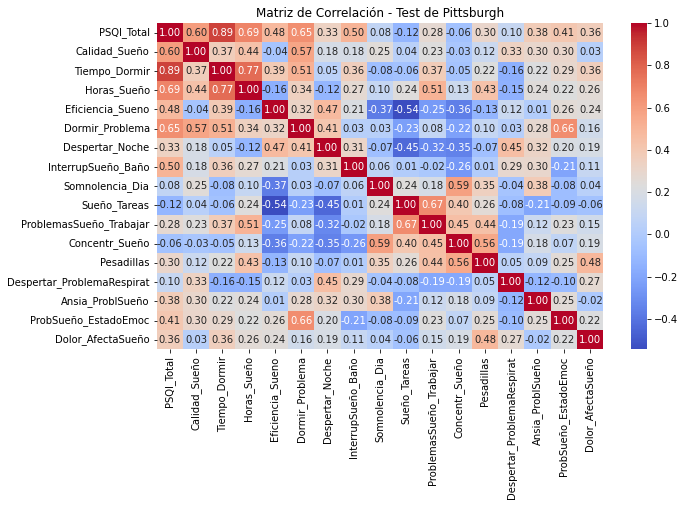

In [168]:
# Seleccionamos las columnas relevantes del Test de Pittsburgh
df_corr = test_pittsburgh[columnas].corr()

# Graficamos la matriz de correlación
plt.figure(figsize=(10, 6))
sns.heatmap(df_corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Matriz de Correlación - Test de Pittsburgh")
plt.show()

In [169]:
columnas_relevantes = ["PSQI_Total","Calidad_Sueño", "Tiempo_Dormir","Horas_Sueño","Tiempo_Dormir","Dormir_Problema","Somnolencia_Dia","ProblemasSueño_Trabajar"]

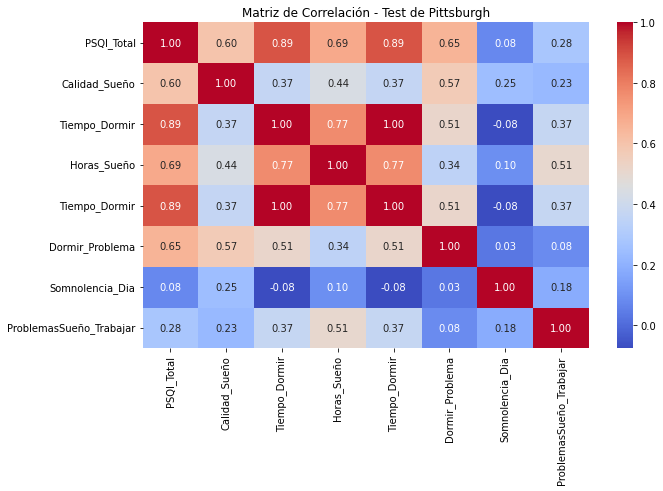

In [170]:
# Seleccionamos las columnas relevantes del Test de Pittsburgh
df_corr = test_pittsburgh[columnas_relevantes].corr()

# Graficamos la matriz de correlación
plt.figure(figsize=(10, 6))
sns.heatmap(df_corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Matriz de Correlación - Test de Pittsburgh")
plt.show()

Por otro lado, nuestro test creado no es tal cual el propuesto por otros estudios, de manera que se ha dado importancia a otros factores y condiciones. Por ello, se ha decidido tomar otra alternativa y basarse en **percentiles**.

In [171]:
print(test_pittsburgh.columns)


Index(['Fecha', 'ID_Paciente', 'Edad', 'Peso_Altura', 'Dormir_Problema',
       'Despertar_Noche', 'Despertar_Problema', 'Somnolencia_Dia',
       'Pesadillas', 'Sueño_Tareas', 'Despertar_ProblemaRespirat',
       'Ansia_ProblSueño', 'Concentr_Sueño', 'DolorCabeza_Mañana',
       'ProbSueño_EstadoEmoc', 'Tiempo_Dormir', 'Horas_Sueño',
       'InterrupSueño_Baño', 'ProblDormir_Preocupac',
       'Dificultades_RutinaSueño', 'Descansado_Frecuencia',
       'ProblemasSueño_Trabajar', 'Dolor_AfectaSueño', 'Calidad_Sueño',
       'Eficiencia_Sueno', 'PSQI_Total'],
      dtype='object')


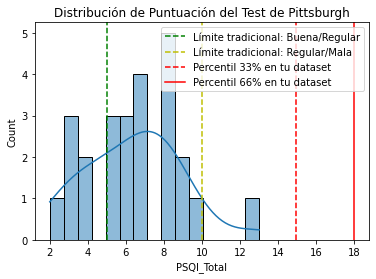

In [172]:
sns.histplot(test_pittsburgh["PSQI_Total"], bins=15, kde=True)
plt.axvline(x=5, color='g', linestyle='--', label="Límite tradicional: Buena/Regular")
plt.axvline(x=10, color='y', linestyle='--', label="Límite tradicional: Regular/Mala")
plt.axvline(x=14.92, color='r', linestyle='--', label="Percentil 33% en tu dataset")
plt.axvline(x=18, color='r', linestyle='-', label="Percentil 66% en tu dataset")
plt.legend()
plt.title("Distribución de Puntuación del Test de Pittsburgh")
plt.show()


In [173]:
# No vale porque se ha optado por calcular la puntuacion como en la literatura cientifica
percentiles = test_pittsburgh["PSQI_Total"].quantile([0.33, 0.66])
print(percentiles)


0.33    5.00
0.66    7.84
Name: PSQI_Total, dtype: float64


In [174]:
# CALCULAR PUNTUACION
#test_pittsburgh["Puntuacion_Final"] = test_pittsburgh[componentes_psqi].sum(axis=1)


In [175]:
# ASIGNAR ETIQUETAS NUMÉRICAS

In [176]:
# Función para asignar etiquetas numéricas
def asignar_etiqueta(puntuacion):
    if puntuacion <= 5:
        return 0  # Buena
    elif puntuacion < 10:
        return 1  # Regular
    else:
        return 2  # Mala

In [177]:
# ASIGNAR ETIQUETAS CATEGÓRICAS

In [178]:
# Función para asignar etiquetas en texto
def asignar_etiqueta_texto(puntuacion):
    if puntuacion <= 5:
        return "Buena"
    elif puntuacion < 10:
        return "Regular"
    else:
        return "Mala"

In [179]:
test_pittsburgh["Calidad_Sueño_Label"] = test_pittsburgh["PSQI_Total"].apply(asignar_etiqueta)
test_pittsburgh["Calidad_Sueño_Texto"] = test_pittsburgh["PSQI_Total"].apply(asignar_etiqueta_texto)

In [180]:
test_pittsburgh.head(30)

,Fecha,ID_Paciente,Edad,Peso_Altura,Dormir_Problema,Despertar_Noche,Despertar_Problema,Somnolencia_Dia,Pesadillas,Sueño_Tareas,...,ProblDormir_Preocupac,Dificultades_RutinaSueño,Descansado_Frecuencia,ProblemasSueño_Trabajar,Dolor_AfectaSueño,Calidad_Sueño,Eficiencia_Sueno,PSQI_Total,Calidad_Sueño_Label,Calidad_Sueño_Texto
0,20/11/2024 10:04:39,Marina,22,63 y 170,1,0,0,1,0,0,...,0,1,2,0,0,1,3,6,1,Regular
1,20/11/2024 10:10:59,Paula,21,56 y 174,1,0,1,2,2,0,...,1,1,1,1,2,1,3,8,1,Regular
2,20/11/2024 10:14:08,Elena,22,53 y 160,1,0,0,0,1,1,...,1,1,1,2,1,1,3,9,1,Regular
3,20/11/2024 10:17:48,Carmen,21,66 y 163,1,0,3,2,1,1,...,1,1,2,1,0,1,0,4,0,Buena
4,20/11/2024 10:21:23,PaulaMunoa,20,52 y 163,2,1,0,1,1,0,...,2,1,1,1,1,1,3,8,1,Regular
5,20/11/2024 11:41:55,Santiago,26,80 y 175,1,0,1,1,2,1,...,1,1,2,1,0,1,2,8,1,Regular
6,20/11/2024 11:47:42,Alvaro,20,78 y 175,0,0,1,1,1,1,...,0,2,1,1,1,1,0,3,0,Buena
7,22/11/2024 10:53:51,Jaime,20,115 y 178,0,0,2,2,1,1,...,0,1,1,1,0,2,0,5,0,Buena
8,24/11/2024 23:22:49,Javier,51,73 kg 174 cm,1,0,0,1,1,1,...,1,1,2,1,1,1,2,7,1,Regular
9,25/11/2024 8:35:13,Ana,46,57 y 173,0,0,3,1,1,1,...,0,1,1,1,1,0,0,2,0,Buena


In [181]:
df_pittsburgh_limpio = test_pittsburgh[["ID_Paciente","Edad","PSQI_Total","Calidad_Sueño_Label","Calidad_Sueño_Texto"]]
df_pittsburgh_limpio.head(30)

,ID_Paciente,Edad,PSQI_Total,Calidad_Sueño_Label,Calidad_Sueño_Texto
0,Marina,22,6,1,Regular
1,Paula,21,8,1,Regular
2,Elena,22,9,1,Regular
3,Carmen,21,4,0,Buena
4,PaulaMunoa,20,8,1,Regular
5,Santiago,26,8,1,Regular
6,Alvaro,20,3,0,Buena
7,Jaime,20,5,0,Buena
8,Javier,51,7,1,Regular
9,Ana,46,2,0,Buena


AQUI VAMOS A CALCULAR LA PUNTUACION CON LOS 7 COMPONENTES PRINCIPALES

In [182]:
def calcular_psqi(respuestas):
    # Componentes
    calidad_sueno = respuestas['calidad_sueno']  # Componente 1
    latencia_sueno = respuestas['latencia_sueno']  # Componente 2
    duracion_sueno = respuestas['duracion_sueno']  # Componente 3
    eficiencia_sueno = respuestas['eficiencia_sueno']  # Componente 4
    despertares = respuestas['despertares']  # Componente 5
    medicamentos = respuestas['medicamentos']  # Componente 6
    disfuncion_diurna = respuestas['disfuncion_diurna']  # Componente 7

    # Puntuación total
    puntaje_total = calidad_sueno + latencia_sueno + duracion_sueno + eficiencia_sueno + \
                    despertares + medicamentos + disfuncion_diurna

    return puntaje_total


In [183]:
display(lista_personas[['Paciente_ID', 'Peso (kg)', 'Altura (m)', 'IMC']].head(10))

,Paciente_ID,Peso (kg),Altura (m),IMC
1,Alvaro,78,1.75,25.469388
3,Carmen,66,1.63,24.840980
4,Paula,56,1.74,18.496499
6,Elena,53,1.60,20.703125
7,Jaime,115,1.78,36.295922
9,Ana,57,1.73,19.045073
10,Julio,93,1.83,27.770313
11,Silvia,53,1.58,21.230572
12,Felix,75,1.73,25.059307
13,Rebeca,54,1.63,20.324438


In [184]:
print(test_pittsburgh[test_pittsburgh["ID_Paciente"] == "Marina"])


                 Fecha ID_Paciente  Edad Peso_Altura  Dormir_Problema  \
0  20/11/2024 10:04:39      Marina    22    63 y 170                1   

   Despertar_Noche  Despertar_Problema  Somnolencia_Dia  Pesadillas  \
0                0                   0                1           0   

   Sueño_Tareas  ...  ProblDormir_Preocupac  Dificultades_RutinaSueño  \
0             0  ...                      0                         1   

   Descansado_Frecuencia  ProblemasSueño_Trabajar  Dolor_AfectaSueño  \
0                      2                        0                  0   

   Calidad_Sueño  Eficiencia_Sueno  PSQI_Total  Calidad_Sueño_Label  \
0              1                 3           6                    1   

   Calidad_Sueño_Texto  
0              Regular  

[1 rows x 28 columns]


## Extracción de Características para la Predicción de la Calidad del Sueño

En este apartado se describen las características extraídas a partir de los datos fisiológicos del **O2Ring** y los datos subjetivos del **Test de Pittsburgh**. Se detalla cómo se han procesado, transformado y seleccionado para su uso en el modelo predictivo.

#### 1. Características Extraídas del O2Ring

El O2Ring proporciona mediciones continuas de varias señales fisiológicas, de las cuales se han extraído las siguientes características clave:

- Saturación de oxígeno (SpO2) [%]: Se ha calculado la media, desviación estándar, mínimo y máximo de la saturación durante el sueño.

- Frecuencia cardíaca (bpm): Se han obtenido las mismas estadísticas (media, desviación, mínimo y máximo) para evaluar variaciones durante la noche.

- Movimiento: Se ha considerado la cantidad de movimientos detectados y su frecuencia.

- Eventos de desaturación: Se han identificado momentos en los que la SpO2 baja de un umbral crítico (<90%).

- Variabilidad de la frecuencia cardíaca (HRV): Se ha calculado para analizar cambios en el ritmo cardíaco, lo cual es un indicador clave de calidad del sueño.

- IAH (Índice de apnea/hipoapnea): se calcula a partir del número de desaturaaciones > o igual al 4%. Para que sea considerado un evento tiene que tener una duraciín mínima de 10 seg.

#### 2. Características Extraídas del Test de Pittsburgh

El Test de Pittsburgh recoge información subjetiva sobre la calidad del sueño de cada participante. Para convertir estas respuestas en variables cuantitativas, se han realizado los siguientes pasos:

**2.1. Transformación de Respuestas Categóricas**

Las preguntas con respuestas cualitativas se han mapeado a valores numéricos para su uso en modelos:

- Frecuencia de problemas de sueño: Convertidas en escala de 0 (nunca) a 3 (siempre).

- Tiempo para quedarse dormido:

    - Menos de 15 min -> 0
    - 16-30 min -> 1
    - 31-60 min -> 2
    - Más de 1 hora -> 3

- Duración del sueño:
    - Más de 7 horas -> 0
    - 6-7 horas -> 1
    - 5-6 horas -> 2
    - Menos de 5 horas -> 3

- Calidad subjetiva del sueño: Valorada de 0 (muy buena) a 3 (muy mala).

**2.2. Cálculo de la Puntuación Total del Test de Pittsburgh**

Para hacer la puntuación comparable con la versión estándar del test, se han agrupado preguntas en bloques equivalentes a los 7 componentes del PSQI:

1. Calidad subjetiva del sueño (Pregunta 20).

2. Latencia del sueño (Pregunta 12).

3. Duración del sueño (Pregunta 13).

4. Trastornos del sueño (Preguntas 2, 5, 7, 14).

5. Disfunción diurna (Preguntas 4, 6, 9, 17, 18).

6. Problemas emocionales y físicos (Preguntas 8, 11, 19).

7. Uso de medicación para dormir: No se incluyó porque ningún participante reportó su uso.

Cada bloque se ha normalizado a una escala de 0 a 3 puntos y sumado para obtener la **puntuación total del Test de Pittsburgh**, con un rango final de 0 a 21.

#### 3. Normalización y Selección de Características

Para mejorar la interpretabilidad y el rendimiento del modelo, se han realizado los siguientes pasos:

- Escalado de variables fisiológicas: Se han normalizado usando min-max scaling para que tengan valores entre 0 y 1.

- Conversión de variables categóricas: Se han transformado en variables numéricas para poder ser utilizadas en modelos de machine learning.

- Eliminación de redundancias: Se han descartado variables que aportaban información duplicada o irrelevante.

#### 4. Creación del Dataset Unificado

Para construir un dataset relevante para la predicción de la calidad del sueño, se ha realizado la **unión de los datos del O2Ringel , la lista de pacientes en Excel y Test de Pittsburgh utilizando el identificador del paciente. La tabla resultante contiene:

- **Datos fisiológicos** del O2Ring, incluyendo métricas de SpO2, HRV y eventos críticos.

- **Variables subjetivas** del Test de Pittsburgh, incluyendo la puntuación total y los componentes del PSQI.

- **Etiquetas de calidad del sueño** en tres niveles: **buena, regular y mala**.

Este dataset final servirá como base para la **construcción y evaluación de modelos predictivos de calidad del sueño**, asegurando que las variables incluidas sean relevantes y significativas para la tarea de predicción.

#### 5. Siguientes Pasos

Con las características extraídas y procesadas, el siguiente paso es la **unión de los datos fisiológicos del O2Ring, la lista de personas de Excel y los datos subjetivos del Test de Pittsburgh** y la posterior **construcción del modelo predictivo**. La clasificación final de la calidad del sueño se hará en tres niveles: **buena, regular y mala**, según los umbrales definidos en el Test de Pittsburgh.

Este enfoque estructurado garantiza que los datos estén listos para entrenar modelos de machine learning de manera eficiente y precisa.

## 5. UNIÓN DATASETS

In [185]:
lista_personas.head()

,Paciente_ID,Edad (años),Peso (kg),Altura (m),IMC,Sexo,Fecha prueba 1,Sexo_Codificado,Calidad_Sueño_Subjet
1,Alvaro,20,78,1.75,25.469388,Masculino,2024-11-12,1,2.0
3,Carmen,21,66,1.63,24.840980,Femenino,2024-11-14,0,4.0
4,Paula,21,56,1.74,18.496499,Femenino,2024-11-17,0,3.0
6,Elena,22,53,1.60,20.703125,Femenino,2024-11-19,0,5.0
7,Jaime,20,115,1.78,36.295922,Masculino,2024-11-21,1,4.0


In [186]:
# ANTES DE LA UNIÓN....

In [214]:
# Antes del cambio
print("IMC antes:")
print(lista_personas[['Paciente_ID', 'IMC']])

# Normaliza SOLO el ID
lista_personas['Paciente_ID'] = lista_personas['Paciente_ID'].astype(str).str.strip().str.lower()
test_pittsburgh['Paciente_ID'] = test_pittsburgh['Paciente_ID'].astype(str).str.strip().str.lower()
#df_features_clean['Paciente_ID'] = features['Paciente_ID'].astype(str).str.strip().str.lower()
# Después del cambio
print("IMC después:")
print(lista_personas[['Paciente_ID', 'IMC']])


IMC antes:
   Paciente_ID        IMC
1       alvaro  25.469388
3       carmen  24.840980
4        paula  18.496499
6        elena  20.703125
7        jaime  36.295922
9          ana  19.045073
10       julio  27.770313
11      silvia  21.230572
12       felix  25.059307
13      rebeca  20.324438
14       pablo  20.603780
15      esther  24.056935
16       rocio  28.010224
17       lucia  22.832879
19       maria  18.732782
20     dolores  29.017447
22     marimar  20.571429
23     roberto  24.337480
24     azucena  23.624447
IMC después:
   Paciente_ID        IMC
1       alvaro  25.469388
3       carmen  24.840980
4        paula  18.496499
6        elena  20.703125
7        jaime  36.295922
9          ana  19.045073
10       julio  27.770313
11      silvia  21.230572
12       felix  25.059307
13      rebeca  20.324438
14       pablo  20.603780
15      esther  24.056935
16       rocio  28.010224
17       lucia  22.832879
19       maria  18.732782
20     dolores  29.017447
22     marimar

In [188]:
# 1. IDENTIFICADORES ÚNICOS en todos los datasets

In [189]:
test_pittsburgh.rename(columns={"ID_Paciente": "Paciente_ID"}, inplace=True)

In [91]:
# NO EJECUTAR POR CAMBIA EL IMC A NUMEROS NEGATIVOS
def normalizar_id(df, columna_nombre):
    df[columna_nombre] = df[columna_nombre].str.strip().str.lower()
    return df

df_o2ring = normalizar_id(df_o2ring, "Paciente_ID")
df_pittsburgh = normalizar_id(test_pittsburgh, "Paciente_ID")
df_personas = normalizar_id(lista_personas, "Paciente_ID")


In [190]:
# 2. FORMATO DE LAS FECHAS (mismo formato)

In [191]:
# Convertir las fechas a formato datetime
df_o2ring["Time"] = pd.to_datetime(df_o2ring["Time"])
df_pittsburgh["Fecha"] = pd.to_datetime(df_pittsburgh["Fecha"])

In [192]:
def check_dates(df1, df2, id_col, date_col1, date_col2):
    merged = df1[[id_col, date_col1]].merge(df2[[id_col, date_col2]], on=id_col, how="inner")
    merged["Date_Diff"] = (merged[date_col1] - merged[date_col2]).dt.days
    print("Diferencias en días entre fechas:")
    print(merged["Date_Diff"].describe())
    return merged

fecha_check = check_dates(df_o2ring, df_pittsburgh, "Paciente_ID", "Time", "Fecha")

Diferencias en días entre fechas:
count    0.0
mean     NaN
std      NaN
min      NaN
25%      NaN
50%      NaN
75%      NaN
max      NaN
Name: Date_Diff, dtype: float64


In [193]:
# 3. VALORES NULOS

In [194]:
print("Valores nulos antes de imputación:")
print(df_personas["Calidad_Sueño_Subjet"].isnull().sum())

Valores nulos antes de imputación:
0


In [195]:
# 4. NORMALIZACIÓN DE VARIABLES

In [196]:
df_o2ring.head()

,Time,SpO2,Frec_Cardiaca,Movimiento,Paciente_ID,z_spo2,z_fc,SpO2_diff,SpO2_drop
0,2024-11-13 00:26:18,96,73,0,Alvaro,0.372795,0.897228,NaN,0
1,2024-11-13 00:26:22,96,73,1,Alvaro,0.372795,0.897228,0.0,0
2,2024-11-13 00:26:26,96,74,0,Alvaro,0.372795,0.995571,0.0,0
3,2024-11-13 00:26:30,96,73,1,Alvaro,0.372795,0.897228,0.0,0
4,2024-11-13 00:26:34,96,72,9,Alvaro,0.372795,0.798884,0.0,0


In [197]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler
scaler_minmax = MinMaxScaler()
scaler_standard = StandardScaler()

vars_to_normalize = ["SpO2", "Frec_Cardiaca", "Movimiento"]

df_o2ring[vars_to_normalize] = scaler_minmax.fit_transform(df_o2ring[vars_to_normalize])
df_personas["IMC"] = scaler_standard.fit_transform(df_personas[["IMC"]])

print("Preprocesamiento completado. Datos listos para la unión.")

Preprocesamiento completado. Datos listos para la unión.


### UNIÓN

In [240]:
# Normalización de nombres
df_o2ring['Paciente_ID'] = df_o2ring['Paciente_ID'].str.strip().str.lower()
test_pittsburgh['Paciente_ID'] = test_pittsburgh['Paciente_ID'].str.strip().str.lower()
lista_personas['Paciente_ID'] = lista_personas['Paciente_ID'].str.strip().str.lower()

# Unimos características extraídas del o2ring + pittsburgh
df_final = features.merge(test_pittsburgh[['Paciente_ID', 'Calidad_Sueño', 'Calidad_Sueño_Label']],
                          on='Paciente_ID', how='inner')

# Añadimos datos demográficos
df_final = df_final.merge(lista_personas[['Paciente_ID', 'Sexo_Codificado', 'Calidad_Sueño_Subjet']],
                          on='Paciente_ID', how='inner')

# Comprobamos
print(df_final.shape)
print(df_final['Calidad_Sueño_Label'].value_counts())


(17, 27)
1    10
0     6
2     1
Name: Calidad_Sueño_Label, dtype: int64


In [241]:
test_pittsburgh.head()

,Fecha,Paciente_ID,Edad,Peso_Altura,Dormir_Problema,Despertar_Noche,Despertar_Problema,Somnolencia_Dia,Pesadillas,Sueño_Tareas,...,ProblDormir_Preocupac,Dificultades_RutinaSueño,Descansado_Frecuencia,ProblemasSueño_Trabajar,Dolor_AfectaSueño,Calidad_Sueño,Eficiencia_Sueno,PSQI_Total,Calidad_Sueño_Label,Calidad_Sueño_Texto
0,20/11/2024 10:04:39,marina,22,63 y 170,1,0,0,1,0,0,...,0,1,2,0,0,1,3,6,1,Regular
1,20/11/2024 10:10:59,paula,21,56 y 174,1,0,1,2,2,0,...,1,1,1,1,2,1,3,8,1,Regular
2,20/11/2024 10:14:08,elena,22,53 y 160,1,0,0,0,1,1,...,1,1,1,2,1,1,3,9,1,Regular
3,20/11/2024 10:17:48,carmen,21,66 y 163,1,0,3,2,1,1,...,1,1,2,1,0,1,0,4,0,Buena
4,20/11/2024 10:21:23,paulamunoa,20,52 y 163,2,1,0,1,1,0,...,2,1,1,1,1,1,3,8,1,Regular


In [216]:
features['Paciente_ID'] = features['Paciente_ID'].astype(str).str.strip().str.lower()
features.head()
#print(features.columns)

,Paciente_ID,SpO2_mean,SpO2_median,SpO2_std,SpO2_min,SpO2_max,FC_mean,FC_median,FC_std,FC_min,...,Porc_Taqui,ODI,Num_Desaturaciones,Num_Taqui,Num_Brady,Movimiento_mean,Movimiento_std,Correlacion_Mov_SpO2,Correlacion_Mov_FC,IAH
0,alvaro,95.172644,95.0,1.004068,89,98,54.524738,53.0,5.918163,41,...,0.000000,0.000000,0,0,1148,1.405759,7.557643,0.017662,0.189545,0.0
1,angel,95.419724,96.0,1.198546,85,98,48.495577,48.0,4.304409,40,...,0.000000,0.000000,0,0,4597,0.392748,3.405878,-0.027561,0.127320,0.0
2,azucena,95.495149,96.0,1.052276,89,98,65.577997,65.0,4.711567,53,...,0.000000,0.000000,0,0,0,0.592924,3.725560,0.042473,0.231971,0.0
3,carmen,96.195554,96.0,0.849797,88,99,74.044908,73.0,10.059083,51,...,0.006308,0.135196,0,42,0,1.948783,7.992162,0.052700,0.181584,0.0
4,cristina,93.197118,93.0,1.218990,86,98,76.078103,76.0,4.092177,65,...,0.001085,0.000000,0,7,0,0.464745,4.672658,-0.024276,0.099487,0.0


In [200]:
lista_personas.head()

,Paciente_ID,Edad (años),Peso (kg),Altura (m),IMC,Sexo,Fecha prueba 1,Sexo_Codificado,Calidad_Sueño_Subjet
1,alvaro,20,78,1.75,25.469388,Masculino,2024-11-12,1,2.0
3,carmen,21,66,1.63,24.840980,Femenino,2024-11-14,0,4.0
4,paula,21,56,1.74,18.496499,Femenino,2024-11-17,0,3.0
6,elena,22,53,1.60,20.703125,Femenino,2024-11-19,0,5.0
7,jaime,20,115,1.78,36.295922,Masculino,2024-11-21,1,4.0


In [201]:
df_features_clean = features.copy()  # Ya tiene solo características fisiológicas


In [202]:
lista_personas.head()

,Paciente_ID,Edad (años),Peso (kg),Altura (m),IMC,Sexo,Fecha prueba 1,Sexo_Codificado,Calidad_Sueño_Subjet
1,alvaro,20,78,1.75,25.469388,Masculino,2024-11-12,1,2.0
3,carmen,21,66,1.63,24.840980,Femenino,2024-11-14,0,4.0
4,paula,21,56,1.74,18.496499,Femenino,2024-11-17,0,3.0
6,elena,22,53,1.60,20.703125,Femenino,2024-11-19,0,5.0
7,jaime,20,115,1.78,36.295922,Masculino,2024-11-21,1,4.0


In [203]:
df_personas_clean = lista_personas[[
    'Paciente_ID',
    'Edad (años)',
    'IMC',
    'Sexo_Codificado',
    'Calidad_Sueño_Subjet'  # Opcional si es un segundo target o quieres compararlo
]]


In [204]:
display(lista_personas[['Paciente_ID', 'Peso (kg)', 'Altura (m)', 'IMC']].head(10))

,Paciente_ID,Peso (kg),Altura (m),IMC
1,alvaro,78,1.75,25.469388
3,carmen,66,1.63,24.840980
4,paula,56,1.74,18.496499
6,elena,53,1.60,20.703125
7,jaime,115,1.78,36.295922
9,ana,57,1.73,19.045073
10,julio,93,1.83,27.770313
11,silvia,53,1.58,21.230572
12,felix,75,1.73,25.059307
13,rebeca,54,1.63,20.324438


In [205]:
df_personas_clean.head()

,Paciente_ID,Edad (años),IMC,Sexo_Codificado,Calidad_Sueño_Subjet
1,alvaro,20,25.469388,1,2.0
3,carmen,21,24.840980,0,4.0
4,paula,21,18.496499,0,3.0
6,elena,22,20.703125,0,5.0
7,jaime,20,36.295922,1,4.0


In [206]:
df_features_clean.head(30)

,Paciente_ID,SpO2_mean,SpO2_median,SpO2_std,SpO2_min,SpO2_max,FC_mean,FC_median,FC_std,FC_min,...,Porc_Taqui,ODI,Num_Desaturaciones,Num_Taqui,Num_Brady,Movimiento_mean,Movimiento_std,Correlacion_Mov_SpO2,Correlacion_Mov_FC,IAH
0,Alvaro,95.172644,95.0,1.004068,89,98,54.524738,53.0,5.918163,41,...,0.000000,0.000000,0,0,1148,1.405759,7.557643,0.017662,0.189545,0.000000
1,Angel,95.419724,96.0,1.198546,85,98,48.495577,48.0,4.304409,40,...,0.000000,0.000000,0,0,4597,0.392748,3.405878,-0.027561,0.127320,0.000000
2,Azucena,95.495149,96.0,1.052276,89,98,65.577997,65.0,4.711567,53,...,0.000000,0.000000,0,0,0,0.592924,3.725560,0.042473,0.231971,0.000000
3,Carmen,96.195554,96.0,0.849797,88,99,74.044908,73.0,10.059083,51,...,0.006308,0.135196,0,42,0,1.948783,7.992162,0.052700,0.181584,0.000000
4,Cristina,93.197118,93.0,1.218990,86,98,76.078103,76.0,4.092177,65,...,0.001085,0.000000,0,7,0,0.464745,4.672658,-0.024276,0.099487,0.000000
5,Dolores,94.839312,95.0,1.953796,79,99,65.953298,66.0,7.458984,47,...,0.000000,0.324949,0,0,4,0.621088,4.056914,0.110338,0.175635,0.108316
6,Elena,97.372144,98.0,0.771523,89,99,49.151800,48.0,4.050680,41,...,0.000000,0.140867,0,0,4562,0.645227,5.274033,-0.002129,0.035644,0.000000
7,Esther,96.404727,96.0,0.703272,92,98,74.187633,74.0,6.598287,56,...,0.003361,0.000000,0,30,0,0.443822,3.394345,0.001618,0.075550,0.000000
8,Felix,93.975703,94.0,1.572358,86,98,71.097785,71.0,6.528599,52,...,0.000476,0.107207,0,4,0,1.439614,8.337265,0.041641,0.082095,0.000000
9,Jaime,97.114625,97.0,0.583768,91,98,57.198123,56.0,6.434412,42,...,0.000988,0.000000,0,2,144,0.985178,4.768053,0.017127,0.081076,0.000000


In [207]:
df_features_clean['Paciente_ID'] = df_features_clean['Paciente_ID'].astype(str).str.strip().str.lower()
df_features_clean.head(30)

,Paciente_ID,SpO2_mean,SpO2_median,SpO2_std,SpO2_min,SpO2_max,FC_mean,FC_median,FC_std,FC_min,...,Porc_Taqui,ODI,Num_Desaturaciones,Num_Taqui,Num_Brady,Movimiento_mean,Movimiento_std,Correlacion_Mov_SpO2,Correlacion_Mov_FC,IAH
0,alvaro,95.172644,95.0,1.004068,89,98,54.524738,53.0,5.918163,41,...,0.000000,0.000000,0,0,1148,1.405759,7.557643,0.017662,0.189545,0.000000
1,angel,95.419724,96.0,1.198546,85,98,48.495577,48.0,4.304409,40,...,0.000000,0.000000,0,0,4597,0.392748,3.405878,-0.027561,0.127320,0.000000
2,azucena,95.495149,96.0,1.052276,89,98,65.577997,65.0,4.711567,53,...,0.000000,0.000000,0,0,0,0.592924,3.725560,0.042473,0.231971,0.000000
3,carmen,96.195554,96.0,0.849797,88,99,74.044908,73.0,10.059083,51,...,0.006308,0.135196,0,42,0,1.948783,7.992162,0.052700,0.181584,0.000000
4,cristina,93.197118,93.0,1.218990,86,98,76.078103,76.0,4.092177,65,...,0.001085,0.000000,0,7,0,0.464745,4.672658,-0.024276,0.099487,0.000000
5,dolores,94.839312,95.0,1.953796,79,99,65.953298,66.0,7.458984,47,...,0.000000,0.324949,0,0,4,0.621088,4.056914,0.110338,0.175635,0.108316
6,elena,97.372144,98.0,0.771523,89,99,49.151800,48.0,4.050680,41,...,0.000000,0.140867,0,0,4562,0.645227,5.274033,-0.002129,0.035644,0.000000
7,esther,96.404727,96.0,0.703272,92,98,74.187633,74.0,6.598287,56,...,0.003361,0.000000,0,30,0,0.443822,3.394345,0.001618,0.075550,0.000000
8,felix,93.975703,94.0,1.572358,86,98,71.097785,71.0,6.528599,52,...,0.000476,0.107207,0,4,0,1.439614,8.337265,0.041641,0.082095,0.000000
9,jaime,97.114625,97.0,0.583768,91,98,57.198123,56.0,6.434412,42,...,0.000988,0.000000,0,2,144,0.985178,4.768053,0.017127,0.081076,0.000000


In [213]:
test_pittsburgh.head(30)

,Fecha,Paciente_ID,Edad,Peso_Altura,Dormir_Problema,Despertar_Noche,Despertar_Problema,Somnolencia_Dia,Pesadillas,Sueño_Tareas,...,ProblDormir_Preocupac,Dificultades_RutinaSueño,Descansado_Frecuencia,ProblemasSueño_Trabajar,Dolor_AfectaSueño,Calidad_Sueño,Eficiencia_Sueno,PSQI_Total,Calidad_Sueño_Label,Calidad_Sueño_Texto
0,20/11/2024 10:04:39,Marina,22,63 y 170,1,0,0,1,0,0,...,0,1,2,0,0,1,3,6,1,Regular
1,20/11/2024 10:10:59,Paula,21,56 y 174,1,0,1,2,2,0,...,1,1,1,1,2,1,3,8,1,Regular
2,20/11/2024 10:14:08,Elena,22,53 y 160,1,0,0,0,1,1,...,1,1,1,2,1,1,3,9,1,Regular
3,20/11/2024 10:17:48,Carmen,21,66 y 163,1,0,3,2,1,1,...,1,1,2,1,0,1,0,4,0,Buena
4,20/11/2024 10:21:23,PaulaMunoa,20,52 y 163,2,1,0,1,1,0,...,2,1,1,1,1,1,3,8,1,Regular
5,20/11/2024 11:41:55,Santiago,26,80 y 175,1,0,1,1,2,1,...,1,1,2,1,0,1,2,8,1,Regular
6,20/11/2024 11:47:42,Alvaro,20,78 y 175,0,0,1,1,1,1,...,0,2,1,1,1,1,0,3,0,Buena
7,22/11/2024 10:53:51,Jaime,20,115 y 178,0,0,2,2,1,1,...,0,1,1,1,0,2,0,5,0,Buena
8,24/11/2024 23:22:49,Javier,51,73 kg 174 cm,1,0,0,1,1,1,...,1,1,2,1,1,1,2,7,1,Regular
9,25/11/2024 8:35:13,Ana,46,57 y 173,0,0,3,1,1,1,...,0,1,1,1,1,0,0,2,0,Buena


In [209]:
df_personas_clean.head(30)

,Paciente_ID,Edad (años),IMC,Sexo_Codificado,Calidad_Sueño_Subjet
1,alvaro,20,25.469388,1,2.0
3,carmen,21,24.840980,0,4.0
4,paula,21,18.496499,0,3.0
6,elena,22,20.703125,0,5.0
7,jaime,20,36.295922,1,4.0
9,ana,46,19.045073,0,4.0
10,julio,53,27.770313,1,4.0
11,silvia,51,21.230572,0,4.0
12,felix,46,25.059307,1,4.0
13,rebeca,47,20.324438,0,4.0


#### UNIÓN

In [218]:
# Merge 1: features + test_pittsburgh
df_merge = df_features_clean.merge(
    test_pittsburgh,
    on='Paciente_ID',
    how='inner'
)

# Merge 2: resultado anterior + lista_personas
df_final = df_merge.merge(
    df_personas_clean,
    on='Paciente_ID',
    how='inner'
)

# Verifica el resultado
#df_final.info()
df_final.head(30)


,Paciente_ID,SpO2_mean,SpO2_median,SpO2_std,SpO2_min,SpO2_max,FC_mean,FC_median,FC_std,FC_min,...,Dolor_AfectaSueño,Calidad_Sueño,Eficiencia_Sueno,PSQI_Total,Calidad_Sueño_Label,Calidad_Sueño_Texto,Edad (años),IMC,Sexo_Codificado,Calidad_Sueño_Subjet
0,alvaro,95.172644,95.0,1.004068,89,98,54.524738,53.0,5.918163,41,...,1,1,0,3,0,Buena,20,25.469388,1,2.0
1,azucena,95.495149,96.0,1.052276,89,98,65.577997,65.0,4.711567,53,...,1,0,3,7,1,Regular,52,23.624447,0,2.0
2,carmen,96.195554,96.0,0.849797,88,99,74.044908,73.0,10.059083,51,...,0,1,0,4,0,Buena,21,24.840980,0,4.0
3,dolores,94.839312,95.0,1.953796,79,99,65.953298,66.0,7.458984,47,...,1,1,3,8,1,Regular,75,29.017447,0,4.0
4,elena,97.372144,98.0,0.771523,89,99,49.151800,48.0,4.050680,41,...,1,1,3,9,1,Regular,22,20.703125,0,5.0
5,esther,96.404727,96.0,0.703272,92,98,74.187633,74.0,6.598287,56,...,0,0,3,4,0,Buena,38,24.056935,0,4.0
6,felix,93.975703,94.0,1.572358,86,98,71.097785,71.0,6.528599,52,...,1,1,3,6,1,Regular,46,25.059307,1,4.0
7,jaime,97.114625,97.0,0.583768,91,98,57.198123,56.0,6.434412,42,...,0,2,0,5,0,Buena,20,36.295922,1,4.0
8,julio,93.200129,93.0,1.453926,84,98,70.908577,70.0,6.245338,59,...,1,1,3,8,1,Regular,53,27.770313,1,4.0
9,lucia,96.644766,97.0,0.618985,94,99,66.932719,67.0,5.204188,52,...,1,1,3,9,1,Regular,21,22.832879,0,4.0


In [242]:
print(df_final.columns)

Index(['Paciente_ID', 'SpO2_mean', 'SpO2_median', 'SpO2_std', 'SpO2_min',
       'SpO2_max', 'FC_mean', 'FC_median', 'FC_std', 'FC_min', 'FC_max',
       'CT90', 'Porc_Bradycardia', 'Porc_Taqui', 'ODI', 'Num_Desaturaciones',
       'Num_Taqui', 'Num_Brady', 'Movimiento_mean', 'Movimiento_std',
       'Correlacion_Mov_SpO2', 'Correlacion_Mov_FC', 'IAH', 'Calidad_Sueño',
       'Calidad_Sueño_Label', 'Sexo_Codificado', 'Calidad_Sueño_Subjet'],
      dtype='object')


In [243]:
# Opciones de y
y = df_final['Calidad_Sueño_Label']  # O usa 'Calidad_Sueño_Subjet' si prefieres

# Variables predictoras (sin el ID ni el target)
X = df_final.drop(columns=['Paciente_ID','Calidad_Sueño_Label','Calidad_Sueño_Subjet'])

# Confirmar
print("Shape de X:", X.shape)
print("Shape de y:", y.shape)


Shape de X: (17, 24)
Shape de y: (17,)


## 6. BALANCEO DE CLASES 
    (opcional, ir mirando los datos que tenemos)

## 6. ENTRENAMIENTO DE MODELOS

In [244]:
print(y.value_counts())


1    10
0     6
2     1
Name: Calidad_Sueño_Label, dtype: int64


In [245]:
from sklearn.model_selection import train_test_split

# Dividimos en 80% entrenamiento y 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)


Train shape: (13, 24)
Test shape: (4, 24)


#### ENTRENAR EL PRIMER MODELO: RANDOM FOREST

In [246]:
from sklearn.ensemble import RandomForestClassifier

# Instanciamos el modelo
rf_model = RandomForestClassifier(
    n_estimators=100,        # Número de árboles
    class_weight='balanced', # Corrige si hay desbalance
    random_state=42
)

# Entrenamos el modelo
rf_model.fit(X_train, y_train)


RandomForestClassifier(class_weight='balanced', random_state=42)

In [247]:
# Predicciones
y_pred = rf_model.predict(X_test)


In [248]:
# EVALUAR EL MODELO
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, cohen_kappa_score

# Accuracy
print("Accuracy:", accuracy_score(y_test, y_pred))

# Matriz de confusión
print("Matriz de Confusión:\n", confusion_matrix(y_test, y_pred))

# Informe de clasificación
print("Classification Report:\n", classification_report(y_test, y_pred))

# Cohen Kappa
print("Cohen Kappa:", cohen_kappa_score(y_test, y_pred))


Accuracy: 0.5
Matriz de Confusión:
 [[1 2]
 [0 1]]
Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.33      0.50         3
           1       0.33      1.00      0.50         1

    accuracy                           0.50         4
   macro avg       0.67      0.67      0.50         4
weighted avg       0.83      0.50      0.50         4

Cohen Kappa: 0.19999999999999996


Importancia de variables:

FC_max                  1.515392e-01
Porc_Taqui              1.479202e-01
Num_Taqui               8.334316e-02
CT90                    6.347442e-02
Movimiento_mean         5.542667e-02
SpO2_median             4.693970e-02
SpO2_mean               4.689745e-02
SpO2_std                4.611321e-02
FC_std                  4.344472e-02
ODI                     4.287575e-02
SpO2_min                4.106562e-02
Movimiento_std          3.389853e-02
SpO2_max                3.099062e-02
Num_Desaturaciones      2.722235e-02
Correlacion_Mov_FC      2.711281e-02
FC_min                  2.568041e-02
Correlacion_Mov_SpO2    2.064785e-02
Num_Brady               1.750814e-02
FC_mean                 1.630861e-02
FC_median               1.467495e-02
Calidad_Sueño           1.208448e-02
Sexo_Codificado         4.831065e-03
Porc_Bradycardia        7.482480e-18
IAH                     3.899544e-18
dtype: float64


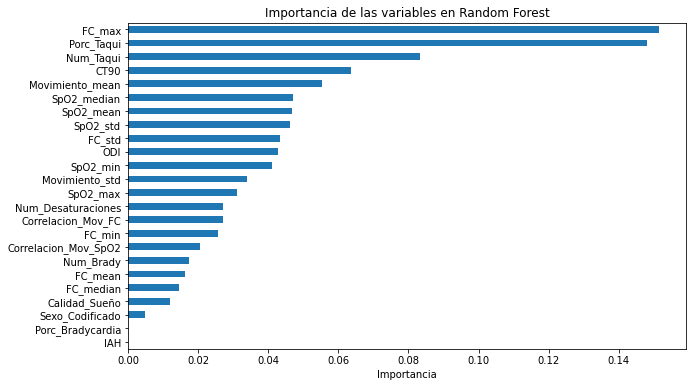

In [249]:
importances = rf_model.feature_importances_
features_importancia = pd.Series(importances, index=X.columns).sort_values(ascending=False)

print("Importancia de variables:\n")
print(features_importancia)

# Opcional: Gráfico
import matplotlib.pyplot as plt

features_importancia.plot(kind='barh', figsize=(10,6))
plt.xlabel("Importancia")
plt.title("Importancia de las variables en Random Forest")
plt.gca().invert_yaxis()
plt.show()


## MODELO SVM

In [250]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [251]:
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix

# Instanciar el modelo
svm_model = SVC(kernel='rbf', C=1, class_weight='balanced', random_state=42)

# Entrenar
svm_model.fit(X_train_scaled, y_train)

# Predecir
y_pred_svm = svm_model.predict(X_test_scaled)

# Evaluar
print("Classification Report (SVM):\n", classification_report(y_test, y_pred_svm))
print("Confusion Matrix (SVM):\n", confusion_matrix(y_test, y_pred_svm))


Classification Report (SVM):
               precision    recall  f1-score   support

           0       1.00      0.33      0.50         3
           1       0.33      1.00      0.50         1

    accuracy                           0.50         4
   macro avg       0.67      0.67      0.50         4
weighted avg       0.83      0.50      0.50         4

Confusion Matrix (SVM):
 [[1 2]
 [0 1]]


## MODELO LOGISTIC REGRESSION

In [252]:
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(multi_class='ovr', solver='lbfgs', class_weight='balanced', random_state=42)

lr_model.fit(X_train_scaled, y_train)

# Predecir
y_pred_lr = lr_model.predict(X_test_scaled)

# Evaluar
print("Classification Report (Logistic Regression):\n", classification_report(y_test, y_pred_lr))
print("Confusion Matrix (Logistic Regression):\n", confusion_matrix(y_test, y_pred_lr))


Classification Report (Logistic Regression):
               precision    recall  f1-score   support

           0       1.00      0.33      0.50         3
           1       0.33      1.00      0.50         1

    accuracy                           0.50         4
   macro avg       0.67      0.67      0.50         4
weighted avg       0.83      0.50      0.50         4

Confusion Matrix (Logistic Regression):
 [[1 2]
 [0 1]]


In [253]:
# REGRESIÓN LOGÍSTICA ORDINAL

In [254]:
pip install mord

Note: you may need to restart the kernel to use updated packages.


In [255]:
import mord

# Usamos el modelo de regresión logística ordinal
ordinal_model = mord.LogisticIT()

# Entrenamos
ordinal_model.fit(X_train_scaled, y_train.astype('category').cat.codes)

# Predecimos
y_pred_ord = ordinal_model.predict(X_test_scaled)

# Evaluamos
from sklearn.metrics import accuracy_score
print("Accuracy:", accuracy_score(y_test.astype('category').cat.codes, y_pred_ord))


Accuracy: 0.5


## XGBoost

In [256]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    objective='multi:softmax',
    num_class=3,
    eval_metric='mlogloss',
    use_label_encoder=False,
    random_state=42
)

xgb_model.fit(X_train, y_train)

y_pred_xgb = xgb_model.predict(X_test)

print("Classification Report (XGBoost):\n", classification_report(y_test, y_pred_xgb))
print("Confusion Matrix (XGBoost):\n", confusion_matrix(y_test, y_pred_xgb))


Classification Report (XGBoost):
               precision    recall  f1-score   support

           0       1.00      0.33      0.50         3
           1       0.33      1.00      0.50         1

    accuracy                           0.50         4
   macro avg       0.67      0.67      0.50         4
weighted avg       0.83      0.50      0.50         4

Confusion Matrix (XGBoost):
 [[1 2]
 [0 1]]


C:\Users\Marina\anaconda3\lib\site-packages\xgboost\sklearn.py:1395: UserWarning: `use_label_encoder` is deprecated in 1.7.0.
  warnings.warn("`use_label_encoder` is deprecated in 1.7.0.")


## LightGBM

In [257]:
from lightgbm import LGBMClassifier

lgb_model = LGBMClassifier(
    objective='multiclass',
    num_class=3,
    class_weight='balanced',
    random_state=42
)

lgb_model.fit(X_train, y_train)
y_pred_lgb = lgb_model.predict(X_test)

print(classification_report(y_test, y_pred_lgb))
print(confusion_matrix(y_test, y_pred_lgb))


[LightGBM] [Warning] There are no meaningful features which satisfy the provided configuration. Decreasing Dataset parameters min_data_in_bin or min_data_in_leaf and re-constructing Dataset might resolve this warning.
[LightGBM] [Info] Total Bins 0
[LightGBM] [Info] Number of data points in the train set: 13, number of used features: 0
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the

C:\Users\Marina\anaconda3\lib\site-packages\sklearn\metrics\_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\Users\Marina\anaconda3\lib\site-packages\sklearn\metrics\_classification.py:1471: UndefinedMetricWarning: Recall and F-score are ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\Users\Marina\anaconda3\lib\site-packages\sklearn\metrics\_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\Users\Marina\anaconda3\lib\site-packages\sklearn\metrics\